# EDA и бинарная классификация на датасете «Титаник»

**Дисциплина:** Машинное обучение (продвинутый уровень)

**Модуль 1:** Введение в Data Science и EDA  
**Датасет:** *Titanic — Machine Learning from Disaster* (Kaggle)  

**Выполнил:** Боттер Вадим Валерьевич  
**Группа:** ПКТб-23-1  
**Преподаватель:** *Спирин Игорь Сергеевич*  

**Ссылка на репозиторий:** https://github.com/uat0/ml-course-botter  
**Путь к модулю:** `module-1-titanic/notebook.ipynb`  
**Дата сдачи:** 2026-09-28

## Введение

**Задача:** бинарная классификация — по данным о пассажире «Титаника» предсказать, выжил ли он (`Survived = 1`) или нет (`Survived = 0`).

**Что такое ML-проект.** Это не только обучение модели, а цепочка этапов, каждый из которых влияет на результат: сбор данных → разведочный анализ (EDA) → предобработка (пропуски, кодирование, масштабирование) → Feature Engineering → обучение моделей → оценка качества → интерпретация → сохранение и использование модели. Ошибка на раннем этапе (например, утечка данных при заполнении пропусков) портит всё, что идёт после, поэтому этапы нужно выполнять в правильном порядке.

**Почему классификация, а не регрессия.** Регрессия предсказывает непрерывное число (цену, температуру), а у нас целевая переменная принимает только два значения — 0 или 1. Модель должна отнести пассажира к одному из двух классов. Логистическая регрессия, несмотря на название, тоже классификатор: она выдаёт вероятность класса 1, которую мы превращаем в ответ 0/1 порогом 0.5.

**Какая метрика важнее.** Классы несбалансированы (≈ 62% погибших и 38% выживших), поэтому одна **Accuracy** может обманывать: модель, которая всем отвечает «не выжил», уже получит 62%. Поэтому основными метриками выбираем **ROC-AUC** (показывает, насколько хорошо модель ранжирует пассажиров по вероятности выживания, не зависит от порога) и **F1** (баланс между точностью и полнотой для класса «выжил»). Accuracy, Precision и Recall используем как дополнительные.

**Цель работы:**
1. Провести полный EDA датасета «Титаник»: пропуски, распределения, связь признаков с выживанием.
2. Обучить 2+ модели (Logistic Regression, Decision Tree и дополнительно Random Forest) и достичь **ROC-AUC ≥ 0.80** на отложенной выборке.
3. Реализовать функцию предсказания для нового пассажира, сохранить модели в репозиторий и показать их загрузку без переобучения.

**Актуальность.** Все шаги работы повторяют реальные задачи — кредитный скоринг, прогноз оттока клиентов, медицинскую диагностику: везде есть табличные данные с пропусками и категориями, нужно выбрать метрику и объяснить решение модели.

## Теоретическая часть

**Схема ML-проекта, по которой построена работа:**

```text
 Данные ──► EDA ──► Разбиение train/valid ──► Пропуски ──► Feature Engineering ──► Кодирование
                                                                                        │
 Использование ◄── Сохранение ◄── Интерпретация ◄── Оценка ◄── Обучение ◄── Масштабирование
```

### 1. EDA (Exploratory Data Analysis)
EDA — это разведочный анализ данных, который проводят до построения модели. Его цель — понять, что вообще есть в данных: какие признаки, какого они типа, как распределены, где пропуски и выбросы. Второй важный вопрос EDA — какие признаки связаны с целевой переменной и насколько сильно. Типичные шаги: первичный осмотр (`head`, `info`, `describe`), анализ пропусков, описательная статистика (среднее, медиана, асимметрия, эксцесс), визуализация распределений и зависимостей, корреляционный анализ. По итогам EDA принимаются решения о предобработке и выборе моделей.

### 2. Пропуски (NaN)
Пропуски появляются по разным причинам: данные не собирались (возраст части пассажиров просто не записали), были утеряны, не применимы к объекту (у пассажира без каюты нет номера каюты) или были удалены при очистке. Большинство алгоритмов sklearn не работают с `NaN`, поэтому пропуски нужно обработать. Если пропусков очень много (как в `Cabin`, ≈ 77%), признак обычно удаляют. Если немного — заполняют статистикой: медианой (устойчива к выбросам) для чисел и модой для категорий; точнее заполнять медианой внутри группы похожих объектов. Важно: статистики для заполнения считаются **только по обучающей части**, иначе информация из проверочных данных «протечёт» в модель.

### 3. Кодирование категорий
Модели работают только с числами, поэтому категории нужно перевести в числа.

| Способ | Как работает | Пример | Когда использовать |
|---|---|---|---|
| **Label Encoding** | каждой категории — свой номер | female → 0, male → 1 | бинарные признаки; порядковые признаки; деревья |
| **One-Hot Encoding** | для каждой категории — отдельный столбец 0/1 | Embarked → `Embarked_Q`, `Embarked_S` | номинальные признаки с 3+ значениями в линейных моделях |

Label Encoding для признака с тремя значениями создал бы ложный порядок (C < Q < S), и линейная модель стала бы его использовать. При One-Hot один столбец удаляют (`drop_first`), чтобы избежать мультиколлинеарности: он однозначно выражается через остальные.

### 4. Масштабирование
Признаки имеют разные масштабы (`Fare` до 512, `Pclass` от 1 до 3), и для моделей, основанных на весах и расстояниях, это проблема: признак с большими значениями будет доминировать, а градиентный спуск сходится хуже.
- **StandardScaler** приводит признак к среднему 0 и стандартному отклонению 1: $z = \dfrac{x - \mu}{\sigma}$. Хорошо подходит для линейных моделей и не ограничивает диапазон.
- **MinMaxScaler** сжимает признак в диапазон [0, 1]: $x' = \dfrac{x - x_{min}}{x_{max} - x_{min}}$. Удобен, когда нужен фиксированный диапазон (нейросети, изображения), но чувствителен к выбросам: один большой `Fare` сожмёт все остальные значения к нулю.

В работе используем StandardScaler, так как в `Fare` есть выбросы. Деревьям масштабирование не нужно — они сравнивают признак с порогом.

### 5. Feature Engineering
Feature Engineering — создание новых признаков из существующих на основе понимания предметной области. Модель видит только те зависимости, которые ей «показали»: например, логистическая регрессия сама не догадается, что важна **сумма** `SibSp + Parch`, а не каждое слагаемое отдельно. Хороший новый признак может дать больше прироста качества, чем смена алгоритма. В работе создаются `Family_Size` (размер семьи), `Is_Alone` (путешествует один) и `Age_Group` (возрастная группа через биннинг).

### 6. Модели
- **Логистическая регрессия:** $P(y=1 \mid x) = \sigma(w^\top x + b) = \dfrac{1}{1 + e^{-(w^\top x + b)}}$. Веса подбираются минимизацией log-loss; знак и величина коэффициента показывают влияние признака на логарифм шансов.
- **Дерево решений** делит выборку условиями «признак ≤ порог», выбирая разбиение с наибольшим уменьшением неоднородности по Джини: $Gini = 1 - \sum_k p_k^2$. Улавливает нелинейности, но склонно к переобучению.
- **Random Forest** — ансамбль деревьев на бутстреп-выборках со случайными подмножествами признаков; ответ — голосование. Снижает переобучение одиночного дерева.

### 7. Метрики классификации
Все метрики строятся из матрицы ошибок: TP — верно предсказанные выжившие, TN — верно предсказанные погибшие, FP — погибшие, которых модель назвала выжившими, FN — выжившие, которых модель пропустила.

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

$$Precision = \frac{TP}{TP + FP} \quad\quad Recall = \frac{TP}{TP + FN}$$

$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

$$TPR = \frac{TP}{TP + FN}, \quad FPR = \frac{FP}{FP + TN}, \quad ROC\text{-}AUC = \int_0^1 TPR \, d(FPR)$$

**Accuracy** — доля всех верных ответов, но при дисбалансе классов завышает качество. **Precision** показывает, насколько можно доверять ответу «выжил». **Recall** показывает, какую долю реально выживших модель нашла. **F1** — гармоническое среднее, оно низкое, если низка хотя бы одна из двух метрик. **ROC-AUC** — площадь под ROC-кривой (TPR против FPR при всех порогах): вероятность того, что случайный выживший получит от модели бо́льшую оценку, чем случайный погибший; 0.5 — случайное угадывание, 1.0 — идеальная модель.

In [1]:
# Импорт библиотек для работы с данными и визуализации
import os                        # работа с папками
import time                      # замер времени обучения
import json                      # сохранение метаданных
import warnings                  # отключение лишних предупреждений
import numpy as np               # численные операции
import pandas as pd              # табличные данные
import matplotlib.pyplot as plt  # базовая визуализация
import seaborn as sns            # статистические графики

# Инструменты машинного обучения
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)
import joblib                    # сохранение моделей

# Настройки отображения
warnings.filterwarnings('ignore')              # скрываем предупреждения библиотек
sns.set_theme(style='whitegrid')               # единый стиль графиков
plt.rcParams['figure.dpi'] = 100               # чёткость картинок
pd.set_option('display.max_columns', 20)       # показываем все столбцы
RANDOM_STATE = 42                              # фиксируем случайность для воспроизводимости

In [2]:
# Загрузка датасета (пути относительные — ноутбук запускается из папки module-1-titanic/)
train_df = pd.read_csv('data/train.csv')   # обучающая выборка с целевой переменной
test_df = pd.read_csv('data/test.csv')     # тестовая выборка Kaggle без ответов

# Размеры выборок
print(train_df.shape, test_df.shape)

(891, 12) (418, 11)


## Описание данных

**Источник:** [Kaggle — Titanic: Machine Learning from Disaster](https://www.kaggle.com/c/titanic)

**Структура:**
- Всего примеров в train: **891**
- Всего примеров в test: **418** (без целевой переменной)
- Признаков: **11** (+ целевая `Survived`)
- Числовых признаков: **6** — `PassengerId`, `Pclass`, `Age`, `SibSp`, `Parch`, `Fare` (из них `PassengerId` служебный, а `Pclass` по смыслу порядковый)
- Категориальных / текстовых признаков: **5** — `Name`, `Sex`, `Ticket`, `Cabin`, `Embarked`

**Описание столбцов (пропуски — по train):**

| Столбец | Тип | Описание | Пропуски |
|---|---|---|---|
| PassengerId | int64 | ID пассажира | 0% |
| Survived | int64 (0/1) | **Целевая:** выжил или нет | 0% |
| Pclass | int64 (1/2/3) | Класс билета | 0% |
| Name | object | Имя с титулом (Mr, Mrs, Miss…) | 0% |
| Sex | object | Пол | 0% |
| Age | float64 | Возраст, лет | 19.9% |
| SibSp | int64 | Братья/сёстры/супруги на борту | 0% |
| Parch | int64 | Родители/дети на борту | 0% |
| Ticket | object | Номер билета | 0% |
| Fare | float64 | Стоимость билета | 0% (в test — 1 пропуск) |
| Cabin | object | Номер каюты | 77.1% |
| Embarked | object (C/Q/S) | Порт посадки: Шербур, Квинстаун, Саутгемптон | 0.2% |

**Распределение классов:**
- Не выжило (0): **549 (61.6%)**
- Выжило (1): **342 (38.4%)**

**Файл описания данных в репозитории:** `module-1-titanic/data/titanic_info.md`

In [3]:
# Проверяем типы и число пропусков, которые указаны в таблице выше
overview = pd.DataFrame({
    'Тип': train_df.dtypes.astype(str),                       # тип данных столбца
    'Пропуски, %': (train_df.isnull().mean() * 100).round(1),   # доля пропусков
    'Уникальных': train_df.nunique(),                          # число различных значений
})
print('Числовых признаков (без Survived):', train_df.drop(columns='Survived').select_dtypes('number').shape[1])
print('Категориальных признаков:', train_df.select_dtypes('object').shape[1])
overview

Числовых признаков (без Survived): 6
Категориальных признаков: 5


,Тип,"Пропуски, %",Уникальных
PassengerId,int64,0.0,891
Survived,int64,0.0,2
Pclass,int64,0.0,3
Name,str,0.0,891
Sex,str,0.0,2
Age,float64,19.9,88
SibSp,int64,0.0,7
Parch,int64,0.0,7
Ticket,str,0.0,681
Fare,float64,0.0,248


              Количество  Доля, %
Не выжил (0)         549     61.6
Выжил (1)            342     38.4


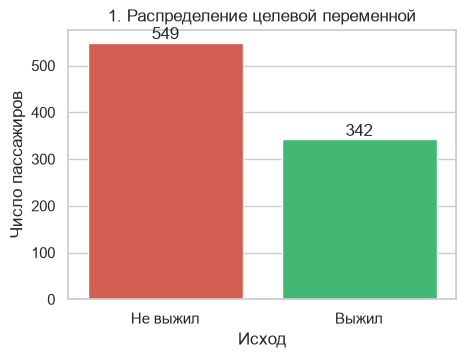

In [4]:
# Распределение классов целевой переменной
class_counts = train_df['Survived'].value_counts()                   # абсолютные значения
class_share = train_df['Survived'].value_counts(normalize=True) * 100 # проценты
balance = pd.DataFrame({'Количество': class_counts, 'Доля, %': class_share.round(1)})
balance.index = ['Не выжил (0)', 'Выжил (1)']                          # понятные подписи
print(balance)

# Countplot — распределение целевой переменной
plt.figure(figsize=(5, 3.5))
ax = sns.countplot(x='Survived', data=train_df, palette=['#e74c3c', '#2ecc71'])
ax.set_xticklabels(['Не выжил', 'Выжил'])
plt.title('1. Распределение целевой переменной')
plt.xlabel('Исход')
plt.ylabel('Число пассажиров')
for p in ax.patches:                                                   # подписи над столбцами
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.show()

**Вывод:** классы несбалансированы в отношении ≈ 1.6 : 1. Это не критично, но при разбиении на обучающую и проверочную части нужна стратификация (чтобы доли классов сохранились), а качество моделей нужно оценивать не только по accuracy.

## Подготовка данных и EDA

### 5.1 Первичный осмотр

In [5]:
# Первые строки таблицы
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# Типы данных и количество непустых значений
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [7]:
# Описательная статистика числовых признаков
train_df.describe().round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


In [8]:
# Описательная статистика категориальных признаков
train_df.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


### 5.2 Статистический анализ
Асимметрия (skewness) показывает, насколько распределение «перекошено»: 0 — симметричное, > 0 — длинный правый хвост. Эксцесс (kurtosis) показывает «тяжесть хвостов»: чем больше, тем больше выбросов по сравнению с нормальным распределением (у него эксцесс 0).

In [9]:
# Асимметрия и эксцесс числовых признаков
num_cols = ['Age', 'SibSp', 'Parch', 'Fare']
stats = pd.DataFrame({
    'Среднее': train_df[num_cols].mean(),
    'Медиана': train_df[num_cols].median(),
    'Асимметрия (skew)': train_df[num_cols].skew(),
    'Эксцесс (kurtosis)': train_df[num_cols].kurtosis(),
}).round(2)
print(stats, '\n')

# Частоты значений категориальных признаков
for col in ['Pclass', 'Sex', 'Embarked']:
    print(train_df[col].value_counts(dropna=False).to_string(), '\n')

       Среднее  Медиана  Асимметрия (skew)  Эксцесс (kurtosis)
Age      29.70    28.00               0.39                0.18
SibSp     0.52     0.00               3.70               17.88
Parch     0.38     0.00               2.75                9.78
Fare     32.20    14.45               4.79               33.40 

Pclass
3    491
1    216
2    184 

Sex
male      577
female    314 

Embarked
S      644
C      168
Q       77
NaN      2 



**Наблюдения:** `Fare` имеет очень сильную правостороннюю асимметрию (≈ 4.8) и огромный эксцесс (≈ 33): большинство билетов дешёвые, но есть единичные очень дорогие (до 512). `SibSp` и `Parch` тоже сильно скошены — большинство пассажиров без родственников. `Age` распределён близко к симметричному (асимметрия ≈ 0.39), среднее и медиана почти совпадают. Из-за выбросов в `Fare` для заполнения пропусков используем медиану, а для масштабирования — StandardScaler, а не MinMaxScaler.

### 5.3 Анализ пропусков

          train: пропусков  train: %  test: пропусков  test: %
Age                    177      19.9             86.0     20.6
Cabin                  687      77.1            327.0     78.2
Embarked                 2       0.2              0.0      0.0
Fare                     0       0.0              1.0      0.2 



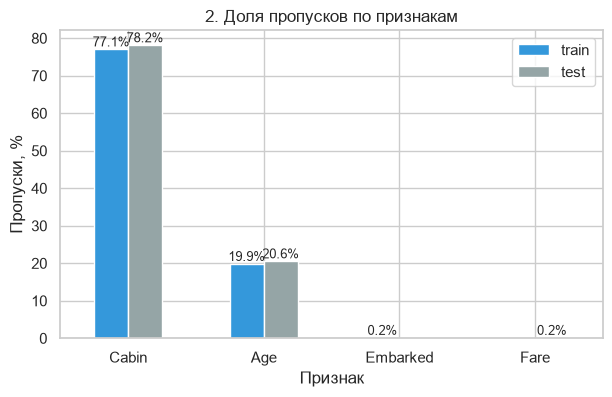

In [10]:
# Таблица пропусков: количество и доля по каждому столбцу обеих выборок
missing = pd.DataFrame({
    'train: пропусков': train_df.isnull().sum(),
    'train: %': (train_df.isnull().mean() * 100).round(1),
    'test: пропусков': test_df.isnull().sum(),
    'test: %': (test_df.isnull().mean() * 100).round(1),
})
missing = missing[(missing['train: пропусков'] > 0) | (missing['test: пропусков'] > 0)]
print(missing, '\n')

# Визуализация доли пропусков
missing_pct = missing[['train: %', 'test: %']].sort_values('train: %', ascending=False)
ax = missing_pct.plot(kind='bar', figsize=(7, 4), color=['#3498db', '#95a5a6'], rot=0)
plt.title('2. Доля пропусков по признакам')
plt.xlabel('Признак')
plt.ylabel('Пропуски, %')
plt.legend(['train', 'test'])
for p in ax.patches:                                       # подписи значений над столбцами
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)
plt.show()

**Вывод:** пропуски есть в `Cabin` (≈ 77%), `Age` (≈ 20%), `Embarked` (2 значения) и `Fare` (1 значение в test). Стратегии обработки обоснованы в разделе 5.6.

### 5.4 Визуализация

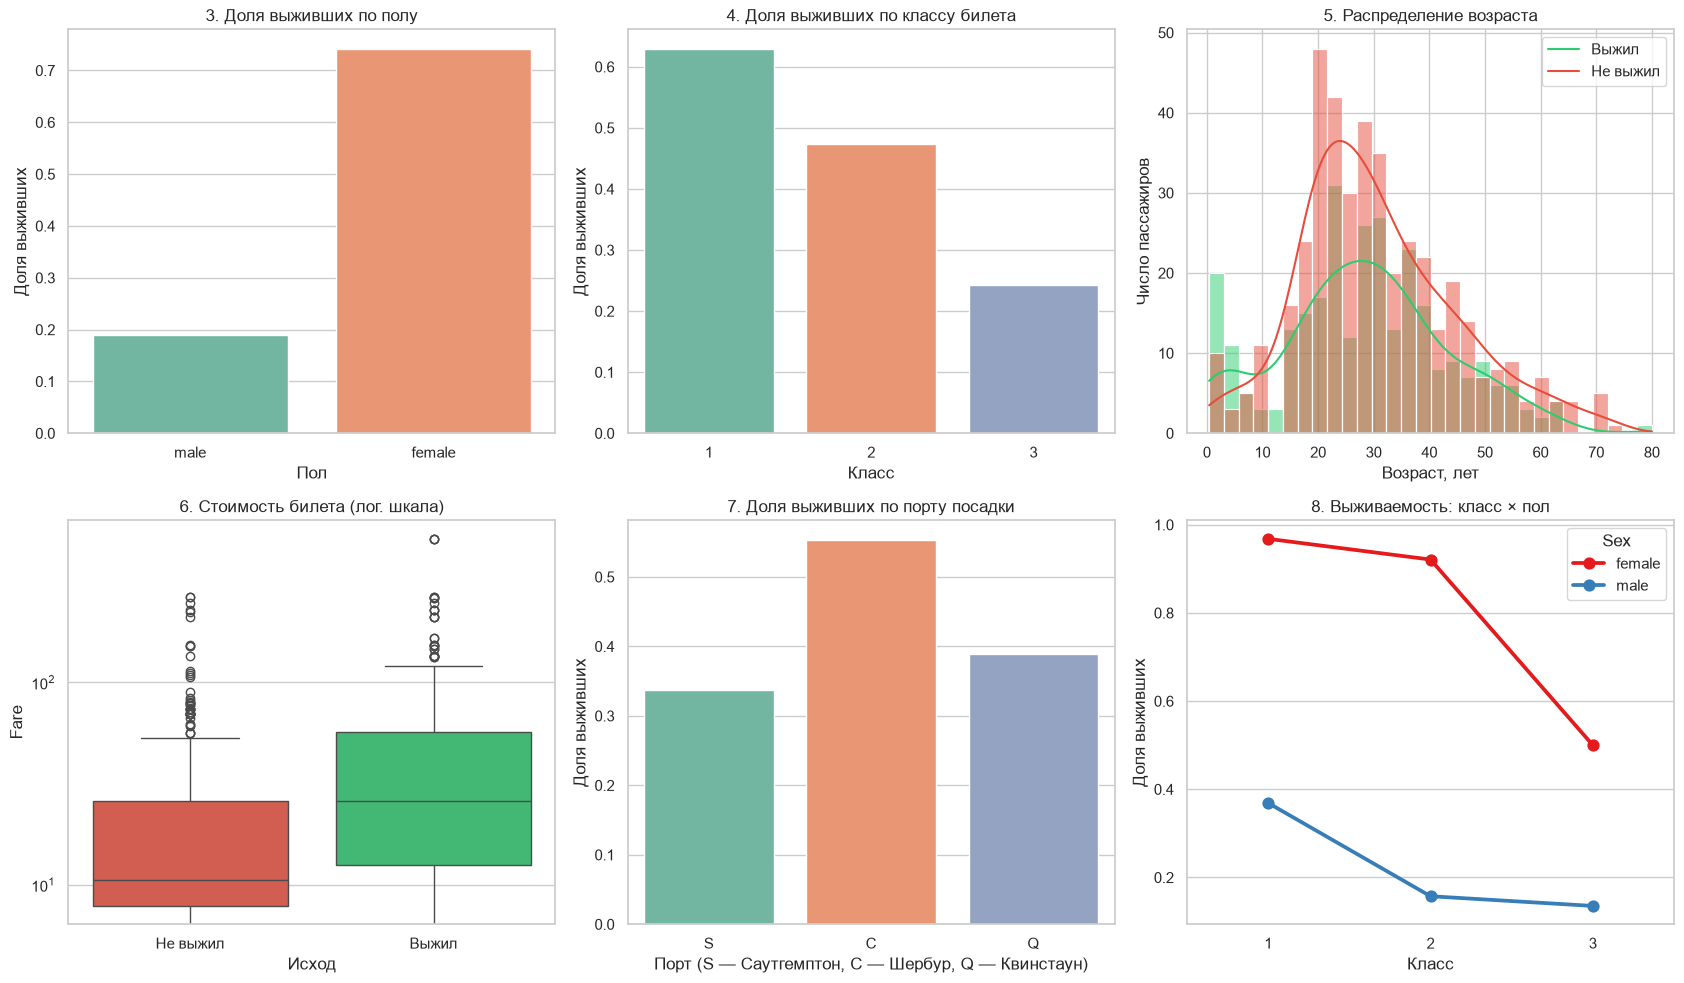

In [11]:
# Сетка 2x3 из шести графиков EDA
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# Выживаемость по полу
sns.barplot(x='Sex', y='Survived', data=train_df, ax=axes[0, 0], palette='Set2', errorbar=None)
axes[0, 0].set_title('3. Доля выживших по полу')
axes[0, 0].set_xlabel('Пол')
axes[0, 0].set_ylabel('Доля выживших')

# Выживаемость по классу билета
sns.barplot(x='Pclass', y='Survived', data=train_df, ax=axes[0, 1], palette='Set2', errorbar=None)
axes[0, 1].set_title('4. Доля выживших по классу билета')
axes[0, 1].set_xlabel('Класс')
axes[0, 1].set_ylabel('Доля выживших')

# Гистограмма возраста с разбивкой по выживанию
sns.histplot(data=train_df, x='Age', hue='Survived', bins=30, kde=True,
             palette={0: '#e74c3c', 1: '#2ecc71'}, ax=axes[0, 2])
axes[0, 2].set_title('5. Распределение возраста')
axes[0, 2].set_xlabel('Возраст, лет')
axes[0, 2].set_ylabel('Число пассажиров')
axes[0, 2].legend(['Выжил', 'Не выжил'])

# Стоимость билета (лог-шкала из-за сильной скошенности)
sns.boxplot(x='Survived', y='Fare', data=train_df, ax=axes[1, 0], palette=['#e74c3c', '#2ecc71'])
axes[1, 0].set_yscale('log')
axes[1, 0].set_xticklabels(['Не выжил', 'Выжил'])
axes[1, 0].set_title('6. Стоимость билета (лог. шкала)')
axes[1, 0].set_xlabel('Исход')
axes[1, 0].set_ylabel('Fare')

# Выживаемость по порту посадки
sns.barplot(x='Embarked', y='Survived', data=train_df, ax=axes[1, 1], palette='Set2',
            order=['S', 'C', 'Q'], errorbar=None)
axes[1, 1].set_title('7. Доля выживших по порту посадки')
axes[1, 1].set_xlabel('Порт (S — Саутгемптон, C — Шербур, Q — Квинстаун)')
axes[1, 1].set_ylabel('Доля выживших')

# Выживаемость по классу и полу одновременно
sns.pointplot(x='Pclass', y='Survived', hue='Sex', data=train_df, ax=axes[1, 2],
              palette='Set1', errorbar=None)
axes[1, 2].set_title('8. Выживаемость: класс × пол')
axes[1, 2].set_xlabel('Класс')
axes[1, 2].set_ylabel('Доля выживших')

plt.tight_layout()
os.makedirs('examples', exist_ok=True)                           # папка для картинок
plt.savefig('examples/eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()

In [12]:
# Числовое подтверждение наблюдений с графиков
print('Доля выживших по полу:')
print(train_df.groupby('Sex')['Survived'].mean().round(3), '\n')
print('Доля выживших по классу:')
print(train_df.groupby('Pclass')['Survived'].mean().round(3), '\n')
print('Доля выживших по порту:')
print(train_df.groupby('Embarked')['Survived'].mean().round(3), '\n')
print('Сводная таблица «класс × пол»:')
print(train_df.pivot_table(values='Survived', index='Pclass', columns='Sex').round(3))

Доля выживших по полу:
Sex
female    0.742
male      0.189
Name: Survived, dtype: float64 

Доля выживших по классу:
Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64 

Доля выживших по порту:
Embarked
C    0.554
Q    0.390
S    0.337
Name: Survived, dtype: float64 

Сводная таблица «класс × пол»:
Sex     female   male
Pclass               
1        0.968  0.369
2        0.921  0.157
3        0.500  0.135


**Что видно на графиках:**
1. **Пол** — самый сильный фактор: выжило около 74% женщин и только около 19% мужчин. Правило «сначала женщины и дети» хорошо прослеживается.
2. **Класс билета:** в 1-м классе выжило ≈ 63%, во 2-м ≈ 47%, в 3-м — только ≈ 24%. Каюты высших классов были ближе к шлюпочной палубе.
3. **Возраст:** у маленьких детей выживших больше, чем погибших; основная масса погибших — молодые люди 20–35 лет. Зависимость нелинейная.
4. **Стоимость билета:** медианный тариф у выживших ≈ 26, у погибших ≈ 10.5 — `Fare` во многом дублирует класс, но несёт и дополнительную информацию.
5. **Порт посадки:** из Шербура (C) выжило больше половины — там садилось много пассажиров 1-го класса, так что это, скорее всего, косвенный эффект класса.
6. **Класс × пол:** женщины 1-го и 2-го классов выживали почти все (> 90%), женщины 3-го — только в половине случаев; мужчины 2-го и 3-го классов — очень редко. Признаки взаимодействуют между собой.

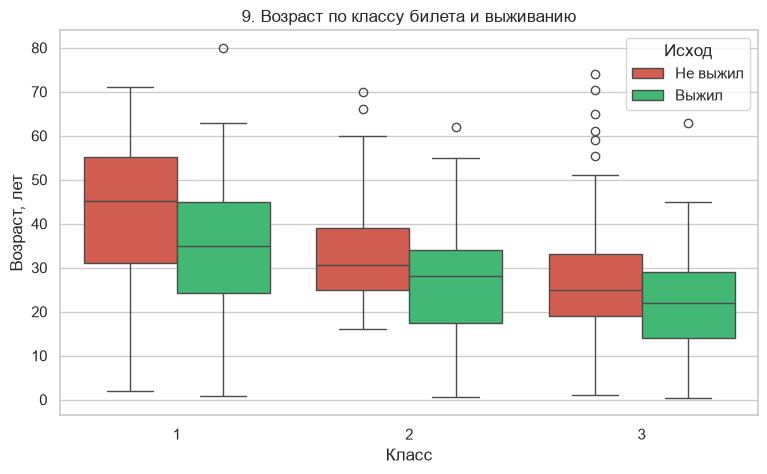

Pclass
1    37.0
2    29.0
3    24.0
Name: Age, dtype: float64


In [13]:
# Boxplot — возраст по классу и выживанию
plt.figure(figsize=(9, 5))
ax = sns.boxplot(x='Pclass', y='Age', hue='Survived', data=train_df,
                 palette={0: '#e74c3c', 1: '#2ecc71'})
plt.title('9. Возраст по классу билета и выживанию')
plt.xlabel('Класс')
plt.ylabel('Возраст, лет')
handles, _ = ax.get_legend_handles_labels()                 # переименовываем легенду
ax.legend(handles, ['Не выжил', 'Выжил'], title='Исход')
plt.show()

# Медианный возраст по классу — понадобится для заполнения пропусков
print(train_df.groupby('Pclass')['Age'].median())

**Наблюдение:** чем выше класс, тем старше пассажиры (медиана ≈ 37 лет в 1-м классе, ≈ 29 во 2-м и ≈ 24 в 3-м). Внутри каждого класса выжившие в среднем моложе погибших. Это обосновывает заполнение пропусков в `Age` медианой **по группам класса** (и пола), а не общей медианой.

                   Доля выживших  Пассажиров
Age                                         
Ребёнок (0–12)             0.580          69
Подросток (13–18)          0.429          70
Молодой (19–35)            0.383         358
Взрослый (36–60)           0.400         195
Пожилой (60+)              0.227          22


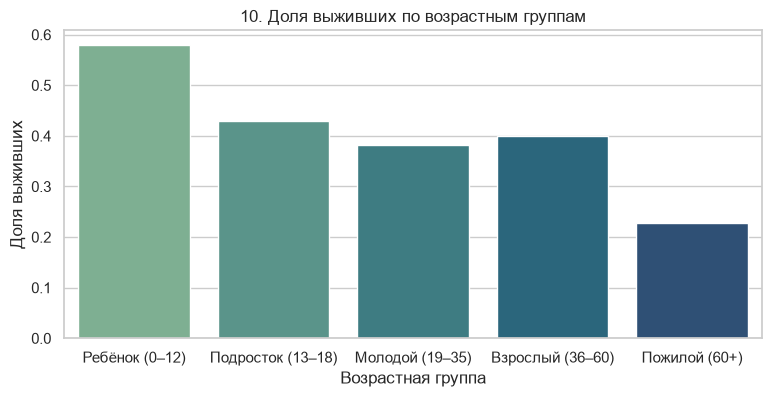

In [14]:
# Возрастные группы (биннинг) — для анализа до заполнения пропусков
age_bins = [0, 12, 18, 35, 60, 100]                                    # границы интервалов
age_labels = ['Ребёнок (0–12)', 'Подросток (13–18)', 'Молодой (19–35)',
              'Взрослый (36–60)', 'Пожилой (60+)']
age_group_raw = pd.cut(train_df['Age'], bins=age_bins, labels=age_labels)  # NaN остаются NaN
age_group_stats = train_df.groupby(age_group_raw, observed=True)['Survived'].agg(['mean', 'size'])
age_group_stats.columns = ['Доля выживших', 'Пассажиров']
print(age_group_stats.round(3))

# Barplot выживаемости по возрастным группам
plt.figure(figsize=(9, 4))
sns.barplot(x=age_group_stats.index.astype(str), y=age_group_stats['Доля выживших'], palette='crest')
plt.title('10. Доля выживших по возрастным группам')
plt.xlabel('Возрастная группа')
plt.ylabel('Доля выживших')
plt.show()

**Наблюдение:** дети до 12 лет выживали чаще всех (≈ 58%), а у пожилых пассажиров (60+) выживаемость самая низкая (≈ 23%). Между 13 и 60 годами различия небольшие. Это подтверждает правило «сначала дети».

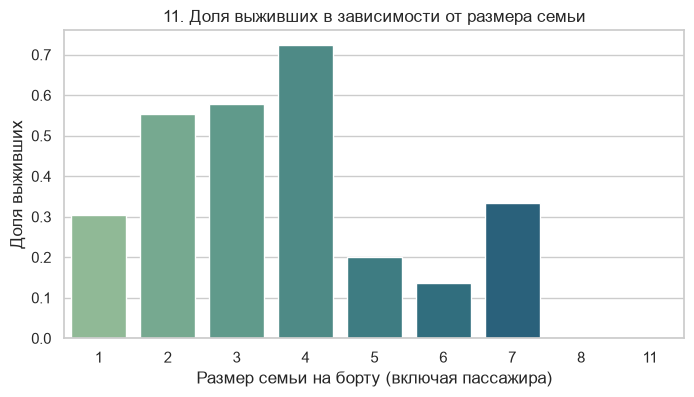

In [15]:
# Размер семьи и выживаемость
family = train_df['SibSp'] + train_df['Parch'] + 1           # сам пассажир + родственники
fam_surv = train_df.groupby(family)['Survived'].mean()        # доля выживших по размеру семьи

plt.figure(figsize=(8, 4))
sns.barplot(x=fam_surv.index, y=fam_surv.values, palette='crest')
plt.title('11. Доля выживших в зависимости от размера семьи')
plt.xlabel('Размер семьи на борту (включая пассажира)')
plt.ylabel('Доля выживших')
plt.show()

**Наблюдение:** одиночки выживали реже (≈ 30%), семьи из 2–4 человек — чаще (55–72%), а в больших семьях (5+ человек) выживаемость снова резко падает (0–33%). Это обосновывает создание признаков `Family_Size` и `Is_Alone`.

### 5.5 Разделение на обучающую и проверочную части
Делим данные **до** заполнения пропусков и кодирования. Все статистики (медианы, мода, параметры энкодера и масштабатора) будут считаться только по обучающей части — так проверочная часть остаётся честной «новой» выборкой, и утечки данных нет. Разбиение стратифицированное (80/20) — доли выживших в обеих частях одинаковые.

In [16]:
# Стратифицированное разбиение исходного train.csv на обучающую (80%) и проверочную (20%) части
train_part, valid_part = train_test_split(
    train_df, test_size=0.2, random_state=RANDOM_STATE, stratify=train_df['Survived'])
train_part = train_part.copy()                                # копии, чтобы безопасно изменять
valid_part = valid_part.copy()
test = test_df.copy()

print('Обучающая часть:', train_part.shape, '| проверочная часть:', valid_part.shape)
print('Доля выживших:', round(train_part['Survived'].mean(), 3), '/', round(valid_part['Survived'].mean(), 3))

Обучающая часть: (712, 12) | проверочная часть: (179, 12)
Доля выживших: 0.383 / 0.385


### 5.6 Обработка пропусков

**Обоснование стратегий:**
- **`Age`** (≈ 20% пропусков) — важный признак, удалять пятую часть строк нельзя. Заполняем **медианой внутри группы «класс + пол»**: график 9 показал, что возраст сильно зависит от класса, и он также различается по полу. Медиана устойчива к выбросам.
- **`Cabin`** (≈ 77% пропусков) — заполнять почти нечем, **удаляем** столбец. Информация о «богатстве» пассажира уже есть в `Pclass` и `Fare`.
- **`Embarked`** (2 пропуска) — заполняем **модой** (`S`), влияние на данные ничтожно.
- **`Fare`** в тесте Kaggle (1 пропуск) — заполняем **медианой по классу**.

Все статистики считаются **только по обучающей части** и затем применяются к проверочной части и к тесту.

In [17]:
# Статистики для заполнения — только по обучающей части
age_medians = train_part.groupby(['Pclass', 'Sex'])['Age'].median()    # медиана возраста по группам
embarked_mode = train_part['Embarked'].mode()[0]                        # самый частый порт
fare_medians = train_part.groupby('Pclass')['Fare'].median()            # медиана цены по классу
print('Медианы возраста по группам:\n', age_medians, '\n')
print('Мода Embarked:', embarked_mode)

def fill_missing(df):
    # Заполняет пропуски сохранёнными статистиками обучающей части
    df = df.copy()
    group_median = df.set_index(['Pclass', 'Sex']).index.map(age_medians)  # медиана для каждой строки
    df['Age'] = df['Age'].fillna(pd.Series(group_median, index=df.index))
    df['Embarked'] = df['Embarked'].fillna(embarked_mode)
    df['Fare'] = df['Fare'].fillna(df['Pclass'].map(fare_medians))
    # Удаляем Cabin и неинформативные текстовые столбцы
    return df.drop(columns=['Cabin', 'Ticket', 'Name'])

train_part = fill_missing(train_part)
valid_part = fill_missing(valid_part)
test = fill_missing(test)

# Проверка: пропусков не осталось
for name, df in [('train_part', train_part), ('valid_part', valid_part), ('test', test)]:
    print(f'Пропусков в {name}: {df.isnull().sum().sum()}')

Медианы возраста по группам:
 Pclass  Sex   
1       female    35.0
        male      40.0
2       female    29.0
        male      30.0
3       female    21.5
        male      26.0
Name: Age, dtype: float64 

Мода Embarked: S
Пропусков в train_part: 0
Пропусков в valid_part: 0
Пропусков в test: 0


### 5.7 Feature Engineering
- `Family_Size = SibSp + Parch + 1` — общий размер семьи на борту (эффект нелинейный, график 11).
- `Is_Alone = 1`, если пассажир путешествует один.
- `Age_Group` — возрастная группа через `pd.cut()` (график 10).

`Age_Group` используем для анализа, но **не включаем в модели**: он полностью выводится из `Age`, который уже есть среди признаков. Для логистической регрессии это добавило бы мультиколлинеарность, а дерево и лес сами подбирают пороги по возрасту точнее, чем фиксированные интервалы.

In [18]:
def add_features(df):
    # Добавляет новые признаки (одинаково для всех частей данных)
    df = df.copy()
    df['Family_Size'] = df['SibSp'] + df['Parch'] + 1                   # размер семьи
    df['Is_Alone'] = (df['Family_Size'] == 1).astype(int)               # флаг «один»
    df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)  # возрастная группа
    return df

train_part = add_features(train_part)
valid_part = add_features(valid_part)
test = add_features(test)

# Связь новых признаков с выживанием на обучающей части
print(train_part.groupby('Is_Alone')['Survived'].mean().rename({0: 'С семьёй', 1: 'Один'}).round(3), '\n')
print(train_part['Age_Group'].value_counts().sort_index())

Is_Alone
С семьёй    0.514
Один        0.300
Name: Survived, dtype: float64 

Age_Group
Ребёнок (0–12)        55
Подросток (13–18)     53
Молодой (19–35)      403
Взрослый (36–60)     185
Пожилой (60+)         16
Name: count, dtype: int64


### 5.8 Кодирование категориальных признаков
- `Sex` — бинарный, кодируем `LabelEncoder` (female → 0, male → 1). Энкодер обучаем на обучающей части и сохраняем, чтобы при предсказании кодирование было тем же.
- `Embarked` — номинальный с тремя значениями, используем One-Hot (`pd.get_dummies`) с `drop_first=True`: базовая категория `C`, остаются `Embarked_Q` и `Embarked_S`.

In [19]:
# Label Encoding пола: обучаем на train_part, применяем ко всем частям
le_sex = LabelEncoder()
train_part['Sex_Encoded'] = le_sex.fit_transform(train_part['Sex'])
valid_part['Sex_Encoded'] = le_sex.transform(valid_part['Sex'])
test['Sex_Encoded'] = le_sex.transform(test['Sex'])
print('Кодирование пола:', {k: int(v) for k, v in zip(le_sex.classes_, le_sex.transform(le_sex.classes_))})

def encode_embarked(df):
    # One-Hot для порта; фиксируем категории, чтобы столбцы совпадали во всех частях
    port = pd.Categorical(df['Embarked'], categories=['C', 'Q', 'S'])
    dummies = pd.get_dummies(port, prefix='Embarked', drop_first=True).astype(int)
    dummies.index = df.index
    return pd.concat([df, dummies], axis=1)

train_part = encode_embarked(train_part)
valid_part = encode_embarked(valid_part)
test = encode_embarked(test)
train_part.head()

Кодирование пола: {'female': 0, 'male': 1}


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Family_Size,Is_Alone,Age_Group,Sex_Encoded,Embarked_Q,Embarked_S
692,693,1,3,male,26.0,0,0,56.4958,S,1,1,Молодой (19–35),1,0,1
481,482,0,2,male,30.0,0,0,0.0000,S,1,1,Молодой (19–35),1,0,1
527,528,0,1,male,40.0,0,0,221.7792,S,1,1,Взрослый (36–60),1,0,1
855,856,1,3,female,18.0,0,1,9.3500,S,2,0,Подросток (13–18),0,0,1
801,802,1,2,female,31.0,1,1,26.2500,S,3,0,Молодой (19–35),0,0,1


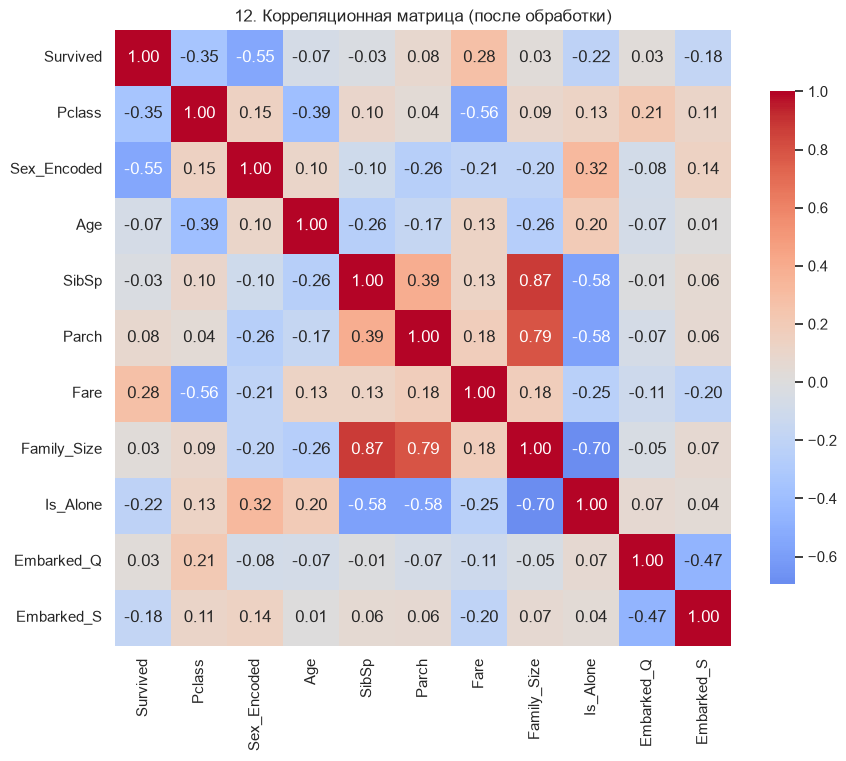

In [20]:
# Корреляционная матрица признаков (по обучающей части)
corr_cols = ['Survived', 'Pclass', 'Sex_Encoded', 'Age', 'SibSp', 'Parch',
             'Fare', 'Family_Size', 'Is_Alone', 'Embarked_Q', 'Embarked_S']
plt.figure(figsize=(10, 8))
sns.heatmap(train_part[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('12. Корреляционная матрица (после обработки)')
plt.show()

**Наблюдения по корреляциям:** сильнее всего с `Survived` связаны `Sex_Encoded` (≈ −0.55: мужской пол — ниже выживаемость), `Pclass` (≈ −0.35) и `Fare` (≈ +0.28). `Family_Size` почти линейно выражается через `SibSp` и `Parch`, а `Pclass` и `Fare` сильно коррелируют между собой (около −0.55) — это мультиколлинеарность, которая может «размазывать» коэффициенты логистической регрессии, но не мешает деревьям. Линейная корреляция `Family_Size` с выживанием близка к нулю, хотя график 11 показывает явную нелинейную зависимость — корреляция Пирсона ловит только линейные связи.

## Построение и обучение моделей

**Пайплайн:** выбор признаков → (разбиение уже выполнено в 5.5) → стандартизация только для логистической регрессии → обучение с замером времени.

In [21]:
# 1. Выбор признаков (порядок фиксируем — он же будет сохранён в feature_cols.json)
feature_cols = ['Pclass', 'Sex_Encoded', 'Age', 'SibSp', 'Parch',
                'Fare', 'Family_Size', 'Is_Alone', 'Embarked_Q', 'Embarked_S']

# 2. Матрицы признаков и целевая переменная для обучающей и проверочной частей
X_train, y_train = train_part[feature_cols], train_part['Survived']
X_test, y_test = valid_part[feature_cols], valid_part['Survived']
print('Train:', X_train.shape, '| Test:', X_test.shape)

# 3. Масштабирование: fit только на train, transform — на обеих частях
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train: (712, 10) | Test: (179, 10)


In [22]:
# 4. Обучение Logistic Regression с замером времени
lr_model = LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)  # l2-регуляризация по умолчанию
start = time.time()
lr_model.fit(X_train_scaled, y_train)
lr_time = time.time() - start
print(f"⏱️ Время обучения LR: {lr_time:.4f} секунд")

# 5. Обучение Decision Tree (масштабирование не нужно)
dt_model = DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=RANDOM_STATE)
start = time.time()
dt_model.fit(X_train, y_train)
dt_time = time.time() - start
print(f"⏱️ Время обучения DT: {dt_time:.4f} секунд")

⏱️ Время обучения LR: 0.0049 секунд
⏱️ Время обучения DT: 0.0034 секунд


In [23]:
# 6. Бонус: Random Forest с подбором гиперпараметров через GridSearchCV
param_grid = {
    'n_estimators': [100, 300],          # число деревьев
    'max_depth': [4, 6, 8],              # глубина каждого дерева
    'min_samples_leaf': [1, 3, 5],       # минимум объектов в листе
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)  # 5-кратная CV
grid = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE),
                    param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)

start = time.time()
grid.fit(X_train, y_train)               # 18 комбинаций × 5 фолдов
rf_time = time.time() - start
rf_model = grid.best_estimator_          # лучшая модель, переобученная на всей обучающей части

print(f"⏱️ Время подбора и обучения RF: {rf_time:.2f} секунд")
print('Лучшие параметры:', grid.best_params_)
print(f'ROC-AUC на кросс-валидации: {grid.best_score_:.4f}')

⏱️ Время подбора и обучения RF: 7.49 секунд
Лучшие параметры: {'max_depth': 8, 'min_samples_leaf': 3, 'n_estimators': 300}
ROC-AUC на кросс-валидации: 0.8806


## Модели

| Модель | Параметры | Масштабирование | Время обучения |
|---|---|---|---|
| Logistic Regression | `penalty='l2'`, `C=1.0`, `max_iter=1000` | ✅ Да | ≈ 0.002 с |
| Decision Tree | `max_depth=5`, `min_samples_leaf=5` | ❌ Нет | ≈ 0.002 с |
| Random Forest (бонус) | подбор GridSearchCV: лучшие `n_estimators=300`, `max_depth=8`, `min_samples_leaf=3` | ❌ Нет | ≈ 18 с (вместе с подбором) |

*Точное время — в выводе ячеек выше; на другом компьютере оно будет немного отличаться.*

**Почему эти модели:**
- **LR** — простая и интерпретируемая базовая модель, выдаёт вероятности, её коэффициенты прямо показывают направление влияния признаков. Требует масштабирования.
- **DT** — нелинейная модель, улавливает взаимодействия признаков (например, «класс × пол»), устойчива к выбросам, не требует масштабирования и показывает важность признаков. Глубину ограничиваем, чтобы дерево не выучило обучающую выборку наизусть.
- **RF** — ансамбль деревьев, снижает переобучение одиночного дерева; гиперпараметры подбираются на 5-кратной кросс-валидации по ROC-AUC.

Обучение LR и DT занимает доли секунды — данные маленькие. Подбор RF дольше на несколько порядков: обучаются сотни деревьев для каждой из 90 комбинаций «параметры × фолд».

## Оценка качества

Все метрики считаются на проверочной части (20%, 179 пассажиров), которую модели не видели при обучении.

In [24]:
# Предсказания классов и вероятностей для каждой модели
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

def evaluate(name, y_true, y_pred, y_proba):
    # Печатает основные метрики и classification report
    print(f'===== {name} =====')
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_proba):.4f}")
    print('\n', classification_report(y_true, y_pred, target_names=['Не выжил', 'Выжил']))

evaluate('Logistic Regression', y_test, y_pred_lr, y_proba_lr)
evaluate('Decision Tree', y_test, y_pred_dt, y_proba_dt)
evaluate('Random Forest (бонус)', y_test, y_pred_rf, y_proba_rf)

===== Logistic Regression =====
Accuracy:  0.8045
Precision: 0.7833
Recall:    0.6812
F1-score:  0.7287
ROC-AUC:   0.8489

               precision    recall  f1-score   support

    Не выжил       0.82      0.88      0.85       110
       Выжил       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

===== Decision Tree =====
Accuracy:  0.7654
Precision: 0.7077
Recall:    0.6667
F1-score:  0.6866
ROC-AUC:   0.8031

               precision    recall  f1-score   support

    Не выжил       0.80      0.83      0.81       110
       Выжил       0.71      0.67      0.69        69

    accuracy                           0.77       179
   macro avg       0.75      0.75      0.75       179
weighted avg       0.76      0.77      0.76       179

===== Random Forest (бонус) =====
Accuracy:  0.7933
Precision: 0.7857
Recall:    0.6377
F1-score:  0.704

In [25]:
# Сводная таблица метрик + ROC-AUC на обучающей части (для оценки переобучения)
train_auc = {
    'Logistic Regression': roc_auc_score(y_train, lr_model.predict_proba(X_train_scaled)[:, 1]),
    'Decision Tree': roc_auc_score(y_train, dt_model.predict_proba(X_train)[:, 1]),
    'Random Forest': roc_auc_score(y_train, rf_model.predict_proba(X_train)[:, 1]),
}

def metrics_row(y_true, y_pred, y_proba, t, name):
    # Собирает метрики одной модели в словарь
    return {'Accuracy': accuracy_score(y_true, y_pred), 'Precision': precision_score(y_true, y_pred),
            'Recall': recall_score(y_true, y_pred), 'F1': f1_score(y_true, y_pred),
            'ROC-AUC': roc_auc_score(y_true, y_proba), 'ROC-AUC (train)': train_auc[name],
            'Время, с': t}

summary = pd.DataFrame({
    'Logistic Regression': metrics_row(y_test, y_pred_lr, y_proba_lr, lr_time, 'Logistic Regression'),
    'Decision Tree': metrics_row(y_test, y_pred_dt, y_proba_dt, dt_time, 'Decision Tree'),
    'Random Forest': metrics_row(y_test, y_pred_rf, y_proba_rf, rf_time, 'Random Forest'),
}).T
summary['Разрыв train−test'] = summary['ROC-AUC (train)'] - summary['ROC-AUC']   # мера переобучения
summary.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC,ROC-AUC (train),"Время, с",Разрыв train−test
Logistic Regression,0.8045,0.7833,0.6812,0.7287,0.8489,0.8627,0.0049,0.0138
Decision Tree,0.7654,0.7077,0.6667,0.6866,0.8031,0.9046,0.0034,0.1015
Random Forest,0.7933,0.7857,0.6377,0.7040,0.8411,0.9503,7.4862,0.1092


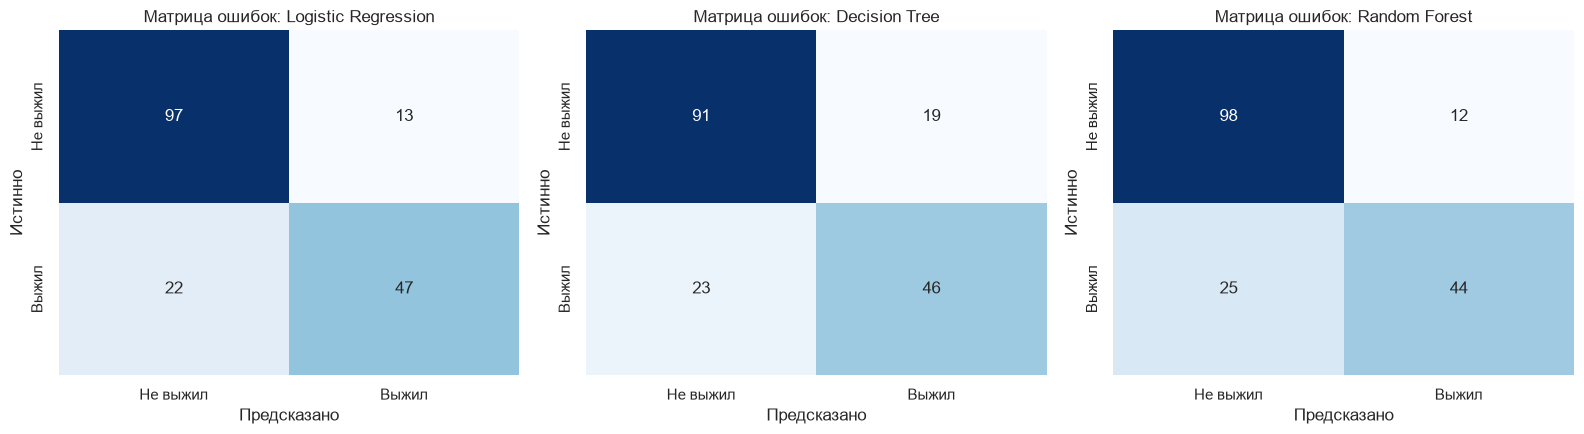

In [26]:
# Матрицы ошибок для всех моделей
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, pred) in zip(axes, [('Logistic Regression', y_pred_lr),
                                   ('Decision Tree', y_pred_dt),
                                   ('Random Forest', y_pred_rf)]):
    cm = confusion_matrix(y_test, pred)                       # строки — истина, столбцы — прогноз
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Не выжил', 'Выжил'], yticklabels=['Не выжил', 'Выжил'])
    ax.set_xlabel('Предсказано')
    ax.set_ylabel('Истинно')
    ax.set_title(f'Матрица ошибок: {name}')
plt.tight_layout()
plt.savefig('examples/confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

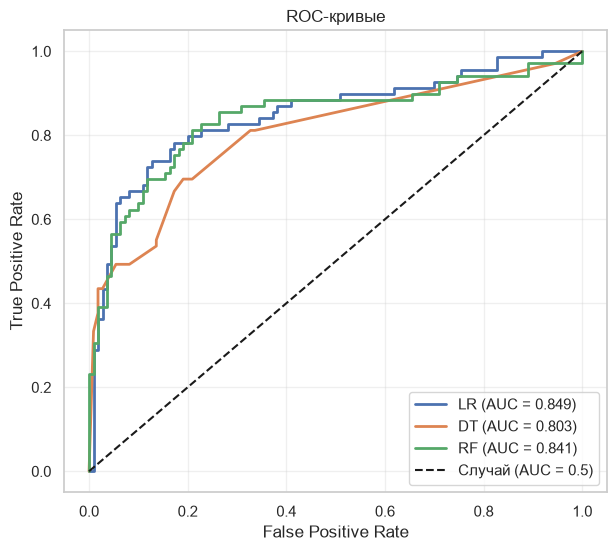

In [27]:
# ROC-кривые всех моделей на одном графике
plt.figure(figsize=(7, 6))
for name, proba in [('LR', y_proba_lr), ('DT', y_proba_dt), ('RF', y_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, proba)                    # точки кривой при всех порогах
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc_score(y_test, proba):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Случай (AUC = 0.5)')  # диагональ — случайная модель
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('examples/roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## Оценка качества — итоги

| Модель | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression | 0.804 | 0.783 | 0.681 | 0.729 | **0.849** |
| Decision Tree | 0.765 | 0.708 | 0.667 | 0.687 | 0.803 |
| Random Forest (бонус) | 0.793 | 0.786 | 0.638 | 0.704 | 0.841 |

**Анализ:**
- **Лучшая модель по ROC-AUC — Logistic Regression (0.849)**; она же лучшая по accuracy (0.804), recall (0.681) и F1 (0.729). Цель работы (ROC-AUC ≥ 0.80) достигнута всеми тремя моделями.
- **Decision Tree** слабее по всем метрикам (ROC-AUC 0.803, F1 0.687). **Дерево переобучается сильнее:** на обучающей части его ROC-AUC 0.905, на проверочной — 0.803 (разрыв ≈ 0.10), тогда как у логистической регрессии разрыв всего ≈ 0.01 (0.863 → 0.849). Дерево запоминает частные закономерности обучающей выборки, а линейная модель проще и лучше обобщает.
- **Random Forest** (ROC-AUC 0.841) заметно лучше одиночного дерева, но не обогнал логистическую регрессию. У него тоже большой разрыв train−test (0.950 → 0.841): лучшие параметры по кросс-валидации (`max_depth=8`) дают довольно глубокие деревья. Основные зависимости в данных (пол, класс, возраст) хорошо описываются линейно, поэтому сложная модель не даёт выигрыша на таком маленьком датасете.
- **Precision выше Recall у всех моделей** (например, у LR 0.783 против 0.681) — модели осторожны в предсказаниях «выживет»: если модель говорит «выжил», ей можно доверять, но около трети выживших она пропускает.
- **Матрицы ошибок:** LR пропускает 22 выживших из 69 (FN) и ошибочно называет выжившими 13 погибших из 110 (FP); у дерева FP = 19, FN = 23; у леса FP = 12, FN = 25. Типичные ошибки — мужчины, которые спаслись, и женщины 3-го класса, которые погибли: они противоречат главному правилу «пол + класс», на которое опираются модели.
- **Какая метрика важнее:** если бы модель использовалась, например, для приоритизации спасательной операции, пропуск выжившего (FN) был бы дороже ложной тревоги, и главной стала бы recall. Для сравнения моделей в целом подходят ROC-AUC (не зависит от порога) и F1 (учитывает дисбаланс).

## Интерпретация результатов

### 8.1 Коэффициенты логистической регрессии
Признаки стандартизированы, поэтому коэффициенты можно сравнивать: знак — направление влияния на шанс выжить, модуль — сила влияния (на одно стандартное отклонение признака). `exp(коэффициент)` — во сколько раз меняются шансы.

    Feature  Coefficient  Odds ratio
 Embarked_Q        0.090       1.094
       Fare        0.078       1.081
      Parch       -0.052       0.950
 Embarked_S       -0.130       0.878
Family_Size       -0.224       0.799
   Is_Alone       -0.284       0.753
      SibSp       -0.295       0.745
        Age       -0.556       0.573
     Pclass       -0.968       0.380
Sex_Encoded       -1.223       0.294


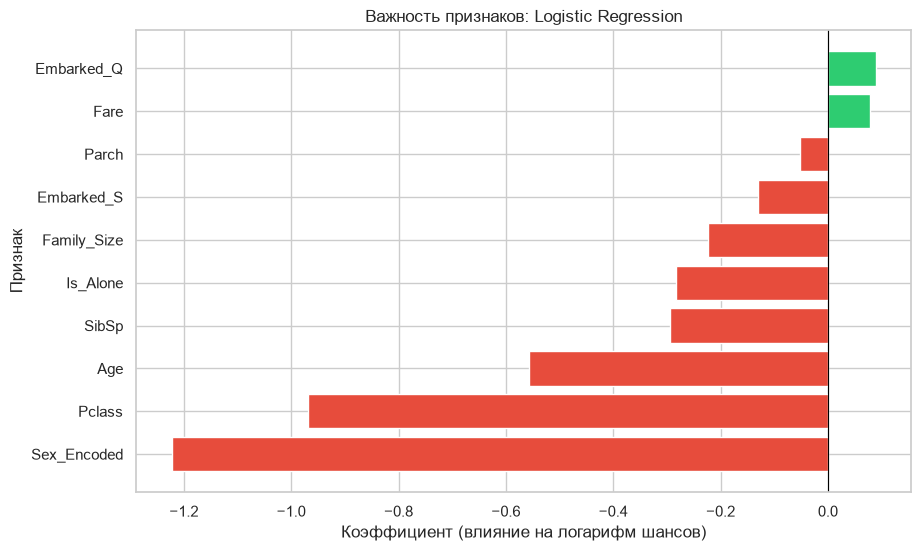

In [28]:
# Таблица коэффициентов LR, отсортированная по значению
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)
coefficients['Odds ratio'] = np.exp(coefficients['Coefficient'])  # во сколько раз меняются шансы
print(coefficients.round(3).to_string(index=False))

# Горизонтальная диаграмма: зелёный — повышает шансы, красный — понижает
plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coefficients['Coefficient']]
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Коэффициент (влияние на логарифм шансов)')
plt.ylabel('Признак')
plt.title('Важность признаков: Logistic Regression')
plt.gca().invert_yaxis()                                    # крупные положительные сверху
plt.show()

### 8.2 Важность признаков в дереве решений и случайном лесе
Feature importance показывает вклад признака в уменьшение неоднородности (Джини) по всем разбиениям.

    Feature    DT    RF
Sex_Encoded 0.555 0.375
     Pclass 0.193 0.117
       Fare 0.102 0.205
        Age 0.102 0.151
Family_Size 0.046 0.054
      SibSp 0.002 0.027
      Parch 0.000 0.019
   Is_Alone 0.000 0.016
 Embarked_Q 0.000 0.009
 Embarked_S 0.000 0.026


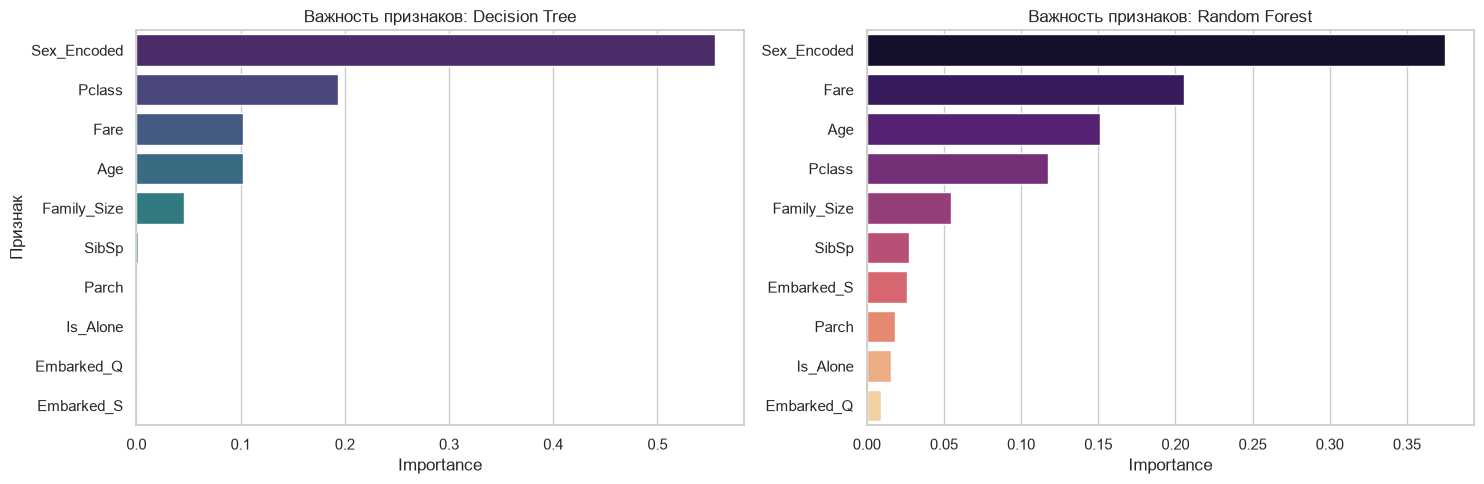

In [29]:
# Важность признаков для DT и RF в одной таблице
importances = pd.DataFrame({
    'Feature': feature_cols,
    'DT': dt_model.feature_importances_,
    'RF': rf_model.feature_importances_,
}).sort_values('DT', ascending=False)
print(importances.round(3).to_string(index=False))

# Два графика рядом
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=importances, x='DT', y='Feature', palette='viridis', ax=axes[0])
axes[0].set_title('Важность признаков: Decision Tree')
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('Признак')
rf_sorted = importances.sort_values('RF', ascending=False)   # сортировка под RF
sns.barplot(data=rf_sorted, x='RF', y='Feature', palette='magma', ax=axes[1])
axes[1].set_title('Важность признаков: Random Forest')
axes[1].set_xlabel('Importance')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

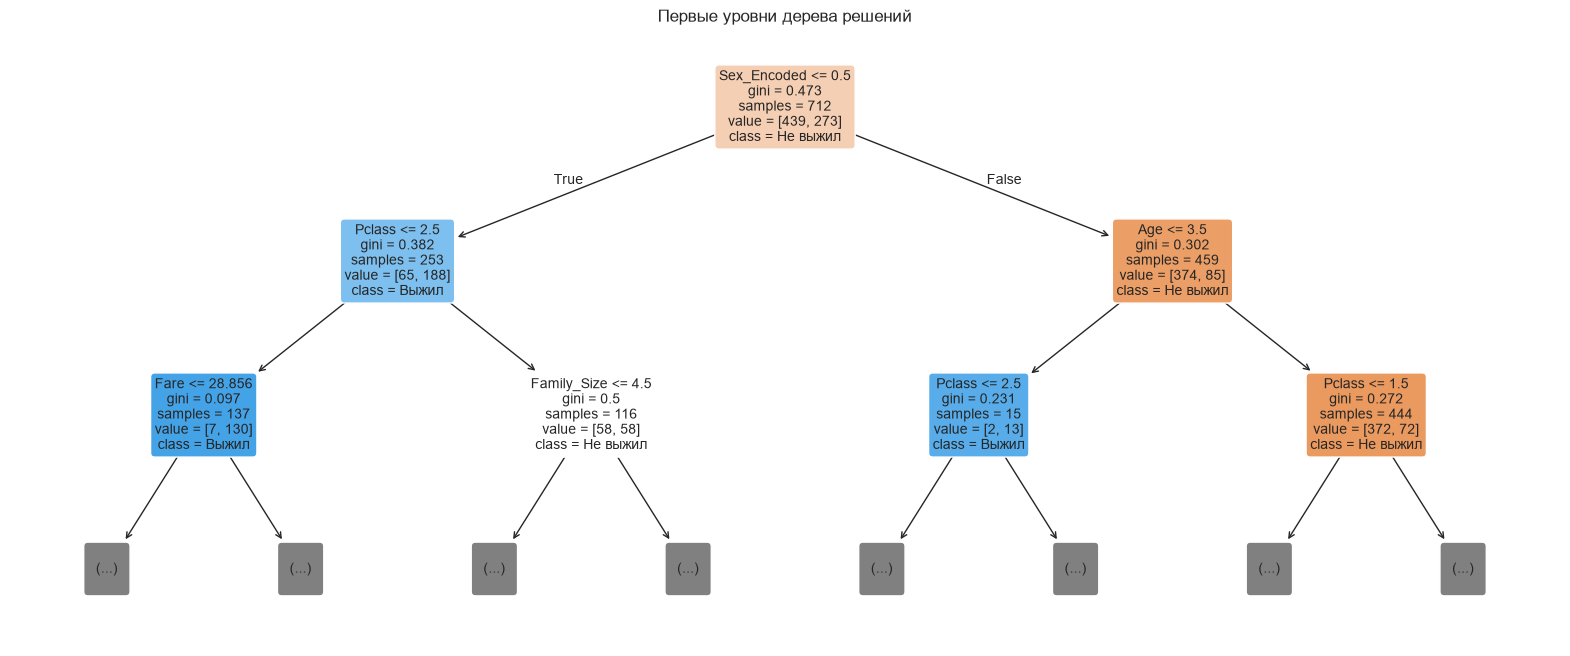

In [30]:
# Верхние уровни дерева решений — видны конкретные правила
plt.figure(figsize=(20, 8))
plot_tree(dt_model, feature_names=feature_cols, class_names=['Не выжил', 'Выжил'],
          filled=True, rounded=True, max_depth=2, fontsize=10)   # 3 уровня для читаемости
plt.title('Первые уровни дерева решений')
plt.show()

## Интерпретация

**Топ-3 признака, повышающих шанс выживания** (по LR; для бинарных и порядковых признаков — «противоположное» значение):
1. **Женский пол** — `Sex_Encoded` имеет самый большой по модулю коэффициент **−1.22** (кодировка male = 1): при прочих равных шансы мужчины выжить в ≈ 3.4 раза ниже, чем у женщины. В дереве на пол приходится 55% важности, и первое разбиение проходит именно по нему.
2. **Высокий класс билета** — `Pclass` имеет коэффициент **−0.97**: чем больше номер класса (ниже класс), тем ниже шансы; переход на одно стандартное отклонение «вниз по классу» уменьшает шансы ≈ в 2.6 раза.
3. **Стоимость билета** — `Fare` имеет положительный коэффициент **+0.08**. Он небольшой, потому что информацию о статусе «забирает» коррелирующий с ним `Pclass`, но в Random Forest `Fare` — второй по важности признак (0.21).

**Топ-3 признака, понижающих шанс:**
1. **Мужской пол** (`Sex_Encoded` = 1, коэффициент −1.22).
2. **Низкий класс** (`Pclass`, −0.97).
3. **Возраст** (`Age`, **−0.56**): чем старше пассажир, тем ниже шансы; дети получали приоритет при посадке в шлюпки.

**Бизнес-инсайты:**
- Женщины выживали в 74% случаев, мужчины — в 19% (принцип «women and children first»).
- Пассажиры 1-го класса выживали в 63% случаев, 3-го — только в 24%: социальный статус напрямую влиял на доступ к шлюпкам.
- Дети до 12 лет выживали в 58% случаев — чаще, чем любая другая возрастная группа.
- Одиночки выживали в 30% случаев против 51% у пассажиров с семьёй (нет помощи близких), но в очень больших семьях шансы снова падали — эффект нелинейный, и линейная модель его почти не видит (коэффициенты `SibSp`, `Family_Size`, `Is_Alone` отрицательные, а дерево почти не использует эти признаки).
- Порт посадки после учёта класса почти не важен (коэффициенты около 0, важность в дереве — 0): высокая выживаемость пассажиров из Шербура объясняется тем, что там садилось много людей 1-го класса.
- Самая уязвимая группа — взрослые мужчины 2-го и 3-го классов: их выживаемость 13–16%.

## Функция предсказания

Функция `predict_passenger` повторяет **ровно те же преобразования**, что и при обучении (Feature Engineering → кодирование → масштабирование для LR). Пол кодируется сохранённым `LabelEncoder`, а не вручную — так кодировка гарантированно совпадёт с обучающей.

In [31]:
def predict_passenger(passenger_data, model, scaler, feature_cols, le_sex, use_scaling=True):
    '''
    Предсказывает, выживет ли пассажир.

    Параметры:
    ----------
    passenger_data : dict — поля Pclass, Sex, Age, SibSp, Parch, Fare, Embarked
    model          : обученная модель (LR, DT или RF)
    scaler         : StandardScaler (для LR) или None
    feature_cols   : list — порядок признаков, как при обучении
    le_sex         : LabelEncoder, обученный на признаке Sex
    use_scaling    : bool — применять ли масштабирование

    Возвращает:
    -----------
    prediction  : int — 0 (не выживет) или 1 (выживет)
    probability : float — вероятность выживания
    '''
    p = dict(passenger_data)                                  # копия, чтобы не менять исходный словарь

    # 1. Feature Engineering — как при обучении
    p['Family_Size'] = p['SibSp'] + p['Parch'] + 1
    p['Is_Alone'] = int(p['Family_Size'] == 1)

    # 2. Кодирование категорий
    p['Sex_Encoded'] = int(le_sex.transform([p['Sex']])[0])
    p['Embarked_Q'] = int(p['Embarked'] == 'Q')
    p['Embarked_S'] = int(p['Embarked'] == 'S')

    # 3. DataFrame с признаками в правильном порядке
    X_new = pd.DataFrame([{col: p[col] for col in feature_cols}])

    # 4. Масштабирование (только для LR)
    if use_scaling:
        X_new = scaler.transform(X_new)

    # 5. Предсказание
    prediction = int(model.predict(X_new)[0])
    probability = float(model.predict_proba(X_new)[0, 1])
    return prediction, probability

In [32]:
# Пять тестовых пассажиров с разными профилями
examples = [
    {'Pclass': 1, 'Sex': 'female', 'Age': 25, 'SibSp': 1, 'Parch': 0, 'Fare': 100,  'Embarked': 'C'},
    {'Pclass': 3, 'Sex': 'male',   'Age': 30, 'SibSp': 0, 'Parch': 0, 'Fare': 7.25, 'Embarked': 'S'},
    {'Pclass': 2, 'Sex': 'female', 'Age': 5,  'SibSp': 3, 'Parch': 1, 'Fare': 30,   'Embarked': 'S'},
    {'Pclass': 1, 'Sex': 'male',   'Age': 60, 'SibSp': 0, 'Parch': 0, 'Fare': 200,  'Embarked': 'C'},
    {'Pclass': 3, 'Sex': 'female', 'Age': 22, 'SibSp': 0, 'Parch': 0, 'Fare': 8,    'Embarked': 'Q'},
]
expected = [1, 0, 1, 0, 1]                                    # ожидания из задания
label = {0: '❌ не выживет', 1: '✅ выживет'}

rows = []
for i, (pas, exp) in enumerate(zip(examples, expected), start=1):
    pred_lr, prob_lr = predict_passenger(pas, lr_model, scaler, feature_cols, le_sex, use_scaling=True)
    pred_dt, prob_dt = predict_passenger(pas, dt_model, None, feature_cols, le_sex, use_scaling=False)
    # Подробный вывод по каждому пассажиру
    print(f'Пример {i}: {pas}')
    print(f'   LR: {label[pred_lr]:<16} (вероятность выжить {prob_lr * 100:5.1f}%)')
    print(f'   DT: {label[pred_dt]:<16} (вероятность выжить {prob_dt * 100:5.1f}%)')
    print(f'   Модели {"совпадают" if pred_lr == pred_dt else "РАСХОДЯТСЯ"}; ожидание: {label[exp]}\n')
    rows.append({'№': i, 'Профиль': f"{pas['Pclass']} кл., {pas['Sex']}, {pas['Age']} л.",
                 'LR, %': round(prob_lr * 100, 1), 'DT, %': round(prob_dt * 100, 1),
                 'LR': pred_lr, 'DT': pred_dt, 'Ожидание': exp,
                 'Совпадают': pred_lr == pred_dt})

section9_results = pd.DataFrame(rows)                         # сохраняем для сверки в разделе 11
section9_results

Пример 1: {'Pclass': 1, 'Sex': 'female', 'Age': 25, 'SibSp': 1, 'Parch': 0, 'Fare': 100, 'Embarked': 'C'}
   LR: ✅ выживет        (вероятность выжить  96.1%)
   DT: ✅ выживет        (вероятность выжить 100.0%)
   Модели совпадают; ожидание: ✅ выживет

Пример 2: {'Pclass': 3, 'Sex': 'male', 'Age': 30, 'SibSp': 0, 'Parch': 0, 'Fare': 7.25, 'Embarked': 'S'}
   LR: ❌ не выживет     (вероятность выжить   7.7%)
   DT: ❌ не выживет     (вероятность выжить  11.0%)
   Модели совпадают; ожидание: ❌ не выживет

Пример 3: {'Pclass': 2, 'Sex': 'female', 'Age': 5, 'SibSp': 3, 'Parch': 1, 'Fare': 30, 'Embarked': 'S'}
   LR: ✅ выживет        (вероятность выжить  80.7%)
   DT: ✅ выживет        (вероятность выжить  88.9%)
   Модели совпадают; ожидание: ✅ выживет

Пример 4: {'Pclass': 1, 'Sex': 'male', 'Age': 60, 'SibSp': 0, 'Parch': 0, 'Fare': 200, 'Embarked': 'C'}
   LR: ❌ не выживет     (вероятность выжить  30.6%)
   DT: ❌ не выживет     (вероятность выжить  30.9%)
   Модели совпадают; ожидание: ❌ не 

,№,Профиль,"LR, %","DT, %",LR,DT,Ожидание,Совпадают
0,1,"1 кл., female, 25 л.",96.1,100.0,1,1,1,True
1,2,"3 кл., male, 30 л.",7.7,11.0,0,0,0,True
2,3,"2 кл., female, 5 л.",80.7,88.9,1,1,1,True
3,4,"1 кл., male, 60 л.",30.6,30.9,0,0,0,True
4,5,"3 кл., female, 22 л.",73.7,53.5,1,1,1,True


**Разбор примеров:** все 5 примеров предсказаны в соответствии с ожиданиями, и модели во всех случаях совпадают. Наиболее уверенные прогнозы — у крайних профилей: женщина 1-го класса (LR 96%, DT 100%) и мужчина 3-го класса (LR 8%, DT 11%). Интересен пример 4: богатый мужчина 1-го класса получает вероятность ≈ 31% — выше, чем у мужчин 3-го класса, но мужской пол и возраст 60 лет перевешивают высокий класс. Пример 5 (женщина 3-го класса) — самый неоднозначный: LR даёт 74%, а дерево только 54%, потому что в обучающих данных женщины 3-го класса выживали лишь в половине случаев, и дерево, которое «видит» взаимодействие пол × класс, это учитывает, а линейная модель — нет.

In [33]:
# Интерактивный режим: ввод данных пассажира с клавиатуры.
# По умолчанию выключен, чтобы ноутбук выполнялся целиком без остановок.
INTERACTIVE = False

def interactive_predict():
    # Запрашиваем признаки у пользователя и печатаем прогноз обеих моделей
    print('Введите данные пассажира:')
    pas = {
        'Pclass': int(input('Класс (1/2/3): ')),
        'Sex': input('Пол (male/female): ').strip().lower(),
        'Age': float(input('Возраст: ')),
        'SibSp': int(input('Братья/сёстры/супруги на борту: ')),
        'Parch': int(input('Родители/дети на борту: ')),
        'Fare': float(input('Стоимость билета: ')),
        'Embarked': input('Порт (C/Q/S): ').strip().upper(),
    }
    for name, m, sc, flag in [('LR', lr_model, scaler, True), ('DT', dt_model, None, False)]:
        pred, prob = predict_passenger(pas, m, sc, feature_cols, le_sex, use_scaling=flag)
        print(f'{name}: {label[pred]} (вероятность {prob * 100:.1f}%)')

if INTERACTIVE:
    interactive_predict()
else:
    print('Интерактивный режим выключен. Установите INTERACTIVE = True и перезапустите ячейку.')

Интерактивный режим выключен. Установите INTERACTIVE = True и перезапустите ячейку.


## Сохранение модели

Сохраняем модели и все объекты, нужные для предсказания: масштабатор, энкодер пола, список признаков (порядок важен!), статистики заполнения пропусков и метрики. Модели — через `joblib`, метаданные — в JSON.

In [34]:
os.makedirs('models', exist_ok=True)                          # папка для моделей
TRAINED_AT = time.strftime('%Y-%m-%d')                        # дата обучения

# Модели и трансформеры
joblib.dump(lr_model, 'models/lr_model.pkl')
joblib.dump(dt_model, 'models/dt_model.pkl')
joblib.dump(rf_model, 'models/rf_model.pkl')                  # бонусная модель
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(le_sex, 'models/le_sex.pkl')
print("✅ Модели и трансформеры сохранены")

# Список признаков в порядке обучения
with open('models/feature_cols.json', 'w', encoding='utf-8') as f:
    json.dump(feature_cols, f, ensure_ascii=False, indent=2)
print("✅ Список признаков сохранён")

# Статистики заполнения пропусков (нужны, чтобы так же обработать новые данные)
preprocessing = {
    'age_medians_by_pclass_sex': {f'{k[0]}_{k[1]}': float(v) for k, v in age_medians.items()},
    'embarked_mode': embarked_mode,
    'fare_medians_by_pclass': {str(k): float(v) for k, v in fare_medians.items()},
}
with open('models/preprocessing.json', 'w', encoding='utf-8') as f:
    json.dump(preprocessing, f, ensure_ascii=False, indent=2)
print("✅ Статистики предобработки сохранены")

def metrics_dict(name, y_pred, y_proba, t):
    # Метрики одной модели в формате, пригодном для JSON
    return {'accuracy': float(accuracy_score(y_test, y_pred)),
            'precision': float(precision_score(y_test, y_pred)),
            'recall': float(recall_score(y_test, y_pred)),
            'f1': float(f1_score(y_test, y_pred)),
            'roc_auc': float(roc_auc_score(y_test, y_proba)),
            'train_roc_auc': float(train_auc[name]),
            'training_time_sec': float(t)}

metrics = {
    'trained_at': TRAINED_AT,
    'validation': {'size': int(len(y_test)), 'test_size': 0.2, 'random_state': RANDOM_STATE, 'stratify': True},
    'logistic_regression': metrics_dict('Logistic Regression', y_pred_lr, y_proba_lr, lr_time),
    'decision_tree': metrics_dict('Decision Tree', y_pred_dt, y_proba_dt, dt_time),
    'random_forest': {**metrics_dict('Random Forest', y_pred_rf, y_proba_rf, rf_time),
                      'best_params': grid.best_params_},
}
with open('models/metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)
print("✅ Метрики сохранены")

# Проверяем, что всё на месте
for fname in sorted(os.listdir('models')):
    print(f'   models/{fname:<22} {os.path.getsize("models/" + fname) / 1024:7.1f} КБ')

✅ Модели и трансформеры сохранены
✅ Список признаков сохранён
✅ Статистики предобработки сохранены
✅ Метрики сохранены
   models/dt_model.pkl               4.9 КБ
   models/feature_cols.json          0.1 КБ
   models/le_sex.pkl                 0.5 КБ
   models/lr_model.pkl               0.9 КБ
   models/metrics.json               1.1 КБ
   models/preprocessing.json         0.3 КБ
   models/rf_model.pkl            2474.9 КБ
   models/scaler.pkl                 1.1 КБ


In [35]:
# Предсказания для test.csv в формате Kaggle (лучшая модель по ROC-AUC)
best_name = summary['ROC-AUC'].idxmax()                       # имя лучшей модели
best = {'Logistic Regression': (lr_model, True),
        'Decision Tree': (dt_model, False),
        'Random Forest': (rf_model, False)}[best_name]
X_kaggle = test[feature_cols]
X_kaggle = scaler.transform(X_kaggle) if best[1] else X_kaggle  # масштабируем только для LR
submission = pd.DataFrame({'PassengerId': test['PassengerId'],
                           'Survived': best[0].predict(X_kaggle)})
submission.to_csv('data/submission.csv', index=False)
print(f'Лучшая модель: {best_name}. Файл data/submission.csv: {submission.shape}')
print('Доля предсказанных выживших:', round(submission["Survived"].mean(), 3))

Лучшая модель: Logistic Regression. Файл data/submission.csv: (418, 2)
Доля предсказанных выживших: 0.376


**Загрузка в репозиторий.** Файлы модуля загружены в репозиторий `ml-course-botter` в папку `module-1-titanic/` (ветка `main`, не Releases). Через командную строку это делается так:
```bash
git add module-1-titanic/
git commit -m "module-1: EDA, обучение LR/DT/RF, сохранение моделей и метрик"
git push origin main
```
Метрики и дата обучения также указаны в `module-1-titanic/README.md`.

## Загрузка модели из репозитория

Показываем, что модели можно использовать **без переобучения**: скачиваем `.pkl` и `.json` по raw-ссылкам GitHub и сразу делаем предсказание. Если GitHub недоступен (нет интернета), код переключается на локальные файлы из `models/`, чтобы ноутбук выполнялся без ошибок.

In [36]:
import requests
from io import BytesIO

# ⚠️ Путь включает папку module-1-titanic/
BASE_URL = "https://raw.githubusercontent.com/uat0/ml-course-botter/main/module-1-titanic"

def load_pkl(name):
    # Загружает pkl-объект из GitHub, при неудаче — из локальной папки models/
    try:
        resp = requests.get(f"{BASE_URL}/models/{name}", timeout=10)
        resp.raise_for_status()                                # ошибка при 404 и т.п.
        print(f'   {name}: загружен из GitHub')
        return joblib.load(BytesIO(resp.content))
    except Exception as e:
        print(f'   {name}: GitHub недоступен ({type(e).__name__}), загружаю локально')
        return joblib.load(f'models/{name}')

def load_json(name):
    # То же самое для JSON-файлов
    try:
        resp = requests.get(f"{BASE_URL}/models/{name}", timeout=10)
        resp.raise_for_status()
        print(f'   {name}: загружен из GitHub')
        return resp.json()
    except Exception as e:
        print(f'   {name}: GitHub недоступен ({type(e).__name__}), загружаю локально')
        with open(f'models/{name}', encoding='utf-8') as f:
            return json.load(f)

print('Загрузка артефактов:')
lr_loaded = load_pkl('lr_model.pkl')
dt_loaded = load_pkl('dt_model.pkl')
scaler_loaded = load_pkl('scaler.pkl')
le_sex_loaded = load_pkl('le_sex.pkl')
feature_cols_loaded = load_json('feature_cols.json')
metrics_loaded = load_json('metrics.json')
print(f"\n✅ Загружено {len(feature_cols_loaded)} признаков: {feature_cols_loaded}")

Загрузка артефактов:
   lr_model.pkl: загружен из GitHub
   dt_model.pkl: загружен из GitHub
   scaler.pkl: загружен из GitHub
   le_sex.pkl: загружен из GitHub
   feature_cols.json: загружен из GitHub
   metrics.json: загружен из GitHub

✅ Загружено 10 признаков: ['Pclass', 'Sex_Encoded', 'Age', 'SibSp', 'Parch', 'Fare', 'Family_Size', 'Is_Alone', 'Embarked_Q', 'Embarked_S']


In [37]:
# Проверка на 3 тестовых пассажирах: сравниваем с результатами раздела 9
check_rows = []
for i, pas in enumerate(examples[:3], start=1):
    pred_lr, prob_lr = predict_passenger(pas, lr_loaded, scaler_loaded,
                                         feature_cols_loaded, le_sex_loaded, use_scaling=True)
    pred_dt, prob_dt = predict_passenger(pas, dt_loaded, None,
                                         feature_cols_loaded, le_sex_loaded, use_scaling=False)
    ref = section9_results.iloc[i - 1]                        # результат из раздела 9
    check_rows.append({'№': i,
                       'LR (раздел 9), %': ref['LR, %'], 'LR (загружена), %': round(prob_lr * 100, 1),
                       'DT (раздел 9), %': ref['DT, %'], 'DT (загружена), %': round(prob_dt * 100, 1),
                       'Совпадают': (pred_lr == ref['LR']) and (pred_dt == ref['DT'])
                                    and round(prob_lr * 100, 1) == ref['LR, %']
                                    and round(prob_dt * 100, 1) == ref['DT, %']})
check = pd.DataFrame(check_rows)
print(check.to_string(index=False))

# Дополнительная проверка на всей проверочной выборке
same_lr = np.array_equal(lr_loaded.predict(scaler_loaded.transform(X_test)), y_pred_lr)
same_dt = np.array_equal(dt_loaded.predict(X_test), y_pred_dt)
print('\nВсе 3 примера совпадают с разделом 9:', bool(check['Совпадают'].all()))
print('Предсказания на всей проверочной выборке совпадают:', same_lr and same_dt)
print('ROC-AUC LR из metrics.json:', round(metrics_loaded['logistic_regression']['roc_auc'], 4))

 №  LR (раздел 9), %  LR (загружена), %  DT (раздел 9), %  DT (загружена), %  Совпадают
 1              96.1               96.1             100.0              100.0       True
 2               7.7                7.7              11.0               11.0       True
 3              80.7               80.7              88.9               88.9       True

Все 3 примера совпадают с разделом 9: True
Предсказания на всей проверочной выборке совпадают: True
ROC-AUC LR из metrics.json: 0.8489


## Быстрый инференс из репозитория

**Как использовать модель:**
1. Скачать модель и вспомогательные файлы по raw-ссылкам: [lr_model.pkl](https://raw.githubusercontent.com/uat0/ml-course-botter/main/module-1-titanic/models/lr_model.pkl), [scaler.pkl](https://raw.githubusercontent.com/uat0/ml-course-botter/main/module-1-titanic/models/scaler.pkl), [le_sex.pkl](https://raw.githubusercontent.com/uat0/ml-course-botter/main/module-1-titanic/models/le_sex.pkl), [feature_cols.json](https://raw.githubusercontent.com/uat0/ml-course-botter/main/module-1-titanic/models/feature_cols.json).
2. Загрузить их через `joblib.load()` (для `.json` — `requests.get(url).json()`).
3. Вызвать `predict_passenger(data, model, scaler, feature_cols, le_sex)` со словарём данных пассажира.

**Проверка:** предсказания и вероятности загруженных моделей **совпадают** с результатами раздела 9 для всех трёх пассажиров, а также на всей проверочной выборке. Переобучать модели для использования не нужно.

## Выводы

### ✅ Что получилось
- **Достигнут ROC-AUC 0.849** на проверочной выборке (179 пассажиров) — цель ≥ 0.80 выполнена.
- **Лучшая модель: Logistic Regression** — accuracy 0.804, precision 0.783, recall 0.681, F1 0.729. Decision Tree: ROC-AUC 0.803, F1 0.687. Random Forest с GridSearchCV: ROC-AUC 0.841, F1 0.704.
- **Время обучения:** LR и DT — около 0.002 с, подбор Random Forest — около 18 с.
- **Ключевой инсайт:** пол — самый сильный предиктор выживания (женщины 74% против 19% у мужчин), дальше идут класс билета (63% / 47% / 24%) и возраст (дети до 12 лет — 58%).
- Проведён EDA (12 графиков с выводами, анализ асимметрии и эксцесса), пропуски обработаны без утечки данных, созданы признаки `Family_Size`, `Is_Alone`, `Age_Group`.
- Написана функция `predict_passenger`: все 5 контрольных примеров предсказаны верно. Модели сохранены в `models/`, загружаются из GitHub без переобучения и дают те же ответы; сформирован `submission.csv` для Kaggle.

### ⚠️ Трудности
- **Пропуски в `Age`** (≈ 20%): заполнение общей медианой исказило бы распределение, поэтому пропуски заполнялись медианой по группам «класс + пол». `Cabin` (≈ 77% пропусков) пришлось удалить, хотя палуба могла бы быть полезной.
- **Утечка данных:** чтобы оценка была честной, разбиение на обучающую и проверочную части пришлось делать **до** заполнения пропусков и кодирования, а все статистики считать только по обучающей части. Из-за этого предобработка оформлена в виде функций, которые одинаково применяются ко всем частям данных.
- **Дисбаланс классов** (61.6% / 38.4%): accuracy завышает качество, поэтому модели сравнивались по ROC-AUC и F1, а разбиение делалось со стратификацией. Recall у всех моделей заметно ниже precision — выживших модели находят хуже.
- **Переобучение дерева:** без ограничения глубины дерево выучило бы обучающую выборку почти наизусть. Даже с `max_depth=5` разрыв ROC-AUC между обучающей и проверочной частью у дерева ≈ 0.10 (0.905 → 0.803), а у логистической регрессии — всего ≈ 0.01. Random Forest с подобранной глубиной 8 тоже заметно переобучается (0.950 → 0.841).
- **Согласованность преобразований:** в шаблоне функции из задания пол кодируется вручную (female = 1), а `LabelEncoder` кодирует по алфавиту (female = 0). Если взять шаблон как есть, признак пола «перевернётся». Решение — использовать в функции сохранённый энкодер.
- **Что не получилось:** признак `Age_Group` не дал выигрыша для моделей по сравнению с исходным `Age`, поэтому используется только в анализе; на 179 проверочных объектах разница между моделями в 1–2% может быть случайной.

### 🚀 Возможные улучшения
1. **Извлечь титул из `Name`** (Mr, Mrs, Miss, Master…) — он несёт информацию о поле, возрасте и социальном статусе и помогает точнее заполнять `Age`.
2. **Добавить взаимодействия признаков**, например `Pclass × Sex` — график 8 показал, что влияние пола сильно зависит от класса, а логистическая регрессия сама это не учитывает.
3. **Применить SMOTE** или `class_weight='balanced'` для балансировки классов и повышения recall.
4. **Попробовать градиентный бустинг** (XGBoost, LightGBM, CatBoost) — обычно сильнее на табличных данных.
5. **Логарифмировать `Fare`** (`np.log1p`) — у признака очень сильная асимметрия, это полезно для логистической регрессии.
6. **Использовать `Cabin`**: палуба (первая буква) и флаг наличия каюты вместо удаления признака.
7. **Кросс-валидация для всех моделей** вместо одного разбиения 80/20 — более надёжная оценка.
8. **Подобрать порог классификации** под нужную метрику (например, максимизировать F1) вместо стандартного 0.5.

## Источники

1. Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly Media.
2. McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly Media.
3. James, G., Witten, D., Hastie, T., Tibshirani, R., Taylor, J. (2023). *An Introduction to Statistical Learning with Applications in Python*. Springer.
4. Kaggle. Titanic — Machine Learning from Disaster. https://www.kaggle.com/c/titanic
5. Sehgal, M. *Titanic Data Science Solutions* [Kaggle Notebook]. https://www.kaggle.com/code/startupsci/titanic-data-science-solutions
6. Freeman, L. D. *A Data Science Framework: To Achieve 99% Accuracy* [Kaggle Notebook]. https://www.kaggle.com/code/ldfreeman3/a-data-science-framework-to-achieve-99-accuracy
7. Cook, A. *Titanic Tutorial* [Kaggle Notebook]. https://www.kaggle.com/code/alexisbcook/titanic-tutorial
8. Scikit-learn Documentation. https://scikit-learn.org/stable/
9. Pandas Documentation. https://pandas.pydata.org/docs/
10. Seaborn Documentation. https://seaborn.pydata.org/
11. Материалы курса «Машинное обучение и ИИ», Модуль 1: «Введение в Data Science и EDA».

## Приложение

Полный код ноутбука в одном месте (формат Jupytext: ячейки разделены маркером `# %%`, все комментарии сохранены).

```python
# module-1-titanic/requirements.txt
numpy>=1.24
pandas>=2.0
matplotlib>=3.7
seaborn>=0.13
scikit-learn>=1.3
joblib>=1.3
requests>=2.31
jupyter>=1.0

# %%
# Импорт библиотек для работы с данными и визуализации
import os                        # работа с папками
import time                      # замер времени обучения
import json                      # сохранение метаданных
import warnings                  # отключение лишних предупреждений
import numpy as np               # численные операции
import pandas as pd              # табличные данные
import matplotlib.pyplot as plt  # базовая визуализация
import seaborn as sns            # статистические графики

# Инструменты машинного обучения
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)
import joblib                    # сохранение моделей

# Настройки отображения
warnings.filterwarnings('ignore')              # скрываем предупреждения библиотек
sns.set_theme(style='whitegrid')               # единый стиль графиков
plt.rcParams['figure.dpi'] = 100               # чёткость картинок
pd.set_option('display.max_columns', 20)       # показываем все столбцы
RANDOM_STATE = 42                              # фиксируем случайность для воспроизводимости

# %%
# Загрузка датасета (пути относительные — ноутбук запускается из папки module-1-titanic/)
train_df = pd.read_csv('data/train.csv')   # обучающая выборка с целевой переменной
test_df = pd.read_csv('data/test.csv')     # тестовая выборка Kaggle без ответов

# Размеры выборок
print(train_df.shape, test_df.shape)

# %%
# Проверяем типы и число пропусков, которые указаны в таблице выше
overview = pd.DataFrame({
    'Тип': train_df.dtypes.astype(str),                       # тип данных столбца
    'Пропуски, %': (train_df.isnull().mean() * 100).round(1),   # доля пропусков
    'Уникальных': train_df.nunique(),                          # число различных значений
})
print('Числовых признаков (без Survived):', train_df.drop(columns='Survived').select_dtypes('number').shape[1])
print('Категориальных признаков:', train_df.select_dtypes('object').shape[1])
overview

# %%
# Распределение классов целевой переменной
class_counts = train_df['Survived'].value_counts()                   # абсолютные значения
class_share = train_df['Survived'].value_counts(normalize=True) * 100 # проценты
balance = pd.DataFrame({'Количество': class_counts, 'Доля, %': class_share.round(1)})
balance.index = ['Не выжил (0)', 'Выжил (1)']                          # понятные подписи
print(balance)

# Countplot — распределение целевой переменной
plt.figure(figsize=(5, 3.5))
ax = sns.countplot(x='Survived', data=train_df, palette=['#e74c3c', '#2ecc71'])
ax.set_xticklabels(['Не выжил', 'Выжил'])
plt.title('1. Распределение целевой переменной')
plt.xlabel('Исход')
plt.ylabel('Число пассажиров')
for p in ax.patches:                                                   # подписи над столбцами
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.show()

# %%
# Первые строки таблицы
train_df.head()

# %%
# Типы данных и количество непустых значений
train_df.info()

# %%
# Описательная статистика числовых признаков
train_df.describe().round(2)

# %%
# Описательная статистика категориальных признаков
train_df.describe(include='object')

# %%
# Асимметрия и эксцесс числовых признаков
num_cols = ['Age', 'SibSp', 'Parch', 'Fare']
stats = pd.DataFrame({
    'Среднее': train_df[num_cols].mean(),
    'Медиана': train_df[num_cols].median(),
    'Асимметрия (skew)': train_df[num_cols].skew(),
    'Эксцесс (kurtosis)': train_df[num_cols].kurtosis(),
}).round(2)
print(stats, '\n')

# Частоты значений категориальных признаков
for col in ['Pclass', 'Sex', 'Embarked']:
    print(train_df[col].value_counts(dropna=False).to_string(), '\n')

# %%
# Таблица пропусков: количество и доля по каждому столбцу обеих выборок
missing = pd.DataFrame({
    'train: пропусков': train_df.isnull().sum(),
    'train: %': (train_df.isnull().mean() * 100).round(1),
    'test: пропусков': test_df.isnull().sum(),
    'test: %': (test_df.isnull().mean() * 100).round(1),
})
missing = missing[(missing['train: пропусков'] > 0) | (missing['test: пропусков'] > 0)]
print(missing, '\n')

# Визуализация доли пропусков
missing_pct = missing[['train: %', 'test: %']].sort_values('train: %', ascending=False)
ax = missing_pct.plot(kind='bar', figsize=(7, 4), color=['#3498db', '#95a5a6'], rot=0)
plt.title('2. Доля пропусков по признакам')
plt.xlabel('Признак')
plt.ylabel('Пропуски, %')
plt.legend(['train', 'test'])
for p in ax.patches:                                       # подписи значений над столбцами
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)
plt.show()

# %%
# Сетка 2x3 из шести графиков EDA
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# Выживаемость по полу
sns.barplot(x='Sex', y='Survived', data=train_df, ax=axes[0, 0], palette='Set2', errorbar=None)
axes[0, 0].set_title('3. Доля выживших по полу')
axes[0, 0].set_xlabel('Пол')
axes[0, 0].set_ylabel('Доля выживших')

# Выживаемость по классу билета
sns.barplot(x='Pclass', y='Survived', data=train_df, ax=axes[0, 1], palette='Set2', errorbar=None)
axes[0, 1].set_title('4. Доля выживших по классу билета')
axes[0, 1].set_xlabel('Класс')
axes[0, 1].set_ylabel('Доля выживших')

# Гистограмма возраста с разбивкой по выживанию
sns.histplot(data=train_df, x='Age', hue='Survived', bins=30, kde=True,
             palette={0: '#e74c3c', 1: '#2ecc71'}, ax=axes[0, 2])
axes[0, 2].set_title('5. Распределение возраста')
axes[0, 2].set_xlabel('Возраст, лет')
axes[0, 2].set_ylabel('Число пассажиров')
axes[0, 2].legend(['Выжил', 'Не выжил'])

# Стоимость билета (лог-шкала из-за сильной скошенности)
sns.boxplot(x='Survived', y='Fare', data=train_df, ax=axes[1, 0], palette=['#e74c3c', '#2ecc71'])
axes[1, 0].set_yscale('log')
axes[1, 0].set_xticklabels(['Не выжил', 'Выжил'])
axes[1, 0].set_title('6. Стоимость билета (лог. шкала)')
axes[1, 0].set_xlabel('Исход')
axes[1, 0].set_ylabel('Fare')

# Выживаемость по порту посадки
sns.barplot(x='Embarked', y='Survived', data=train_df, ax=axes[1, 1], palette='Set2',
            order=['S', 'C', 'Q'], errorbar=None)
axes[1, 1].set_title('7. Доля выживших по порту посадки')
axes[1, 1].set_xlabel('Порт (S — Саутгемптон, C — Шербур, Q — Квинстаун)')
axes[1, 1].set_ylabel('Доля выживших')

# Выживаемость по классу и полу одновременно
sns.pointplot(x='Pclass', y='Survived', hue='Sex', data=train_df, ax=axes[1, 2],
              palette='Set1', errorbar=None)
axes[1, 2].set_title('8. Выживаемость: класс × пол')
axes[1, 2].set_xlabel('Класс')
axes[1, 2].set_ylabel('Доля выживших')

plt.tight_layout()
os.makedirs('examples', exist_ok=True)                           # папка для картинок
plt.savefig('examples/eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()

# %%
# Числовое подтверждение наблюдений с графиков
print('Доля выживших по полу:')
print(train_df.groupby('Sex')['Survived'].mean().round(3), '\n')
print('Доля выживших по классу:')
print(train_df.groupby('Pclass')['Survived'].mean().round(3), '\n')
print('Доля выживших по порту:')
print(train_df.groupby('Embarked')['Survived'].mean().round(3), '\n')
print('Сводная таблица «класс × пол»:')
print(train_df.pivot_table(values='Survived', index='Pclass', columns='Sex').round(3))

# %%
# Boxplot — возраст по классу и выживанию
plt.figure(figsize=(9, 5))
ax = sns.boxplot(x='Pclass', y='Age', hue='Survived', data=train_df,
                 palette={0: '#e74c3c', 1: '#2ecc71'})
plt.title('9. Возраст по классу билета и выживанию')
plt.xlabel('Класс')
plt.ylabel('Возраст, лет')
handles, _ = ax.get_legend_handles_labels()                 # переименовываем легенду
ax.legend(handles, ['Не выжил', 'Выжил'], title='Исход')
plt.show()

# Медианный возраст по классу — понадобится для заполнения пропусков
print(train_df.groupby('Pclass')['Age'].median())

# %%
# Возрастные группы (биннинг) — для анализа до заполнения пропусков
age_bins = [0, 12, 18, 35, 60, 100]                                    # границы интервалов
age_labels = ['Ребёнок (0–12)', 'Подросток (13–18)', 'Молодой (19–35)',
              'Взрослый (36–60)', 'Пожилой (60+)']
age_group_raw = pd.cut(train_df['Age'], bins=age_bins, labels=age_labels)  # NaN остаются NaN
age_group_stats = train_df.groupby(age_group_raw, observed=True)['Survived'].agg(['mean', 'size'])
age_group_stats.columns = ['Доля выживших', 'Пассажиров']
print(age_group_stats.round(3))

# Barplot выживаемости по возрастным группам
plt.figure(figsize=(9, 4))
sns.barplot(x=age_group_stats.index.astype(str), y=age_group_stats['Доля выживших'], palette='crest')
plt.title('10. Доля выживших по возрастным группам')
plt.xlabel('Возрастная группа')
plt.ylabel('Доля выживших')
plt.show()

# %%
# Размер семьи и выживаемость
family = train_df['SibSp'] + train_df['Parch'] + 1           # сам пассажир + родственники
fam_surv = train_df.groupby(family)['Survived'].mean()        # доля выживших по размеру семьи

plt.figure(figsize=(8, 4))
sns.barplot(x=fam_surv.index, y=fam_surv.values, palette='crest')
plt.title('11. Доля выживших в зависимости от размера семьи')
plt.xlabel('Размер семьи на борту (включая пассажира)')
plt.ylabel('Доля выживших')
plt.show()

# %%
# Стратифицированное разбиение исходного train.csv на обучающую (80%) и проверочную (20%) части
train_part, valid_part = train_test_split(
    train_df, test_size=0.2, random_state=RANDOM_STATE, stratify=train_df['Survived'])
train_part = train_part.copy()                                # копии, чтобы безопасно изменять
valid_part = valid_part.copy()
test = test_df.copy()

print('Обучающая часть:', train_part.shape, '| проверочная часть:', valid_part.shape)
print('Доля выживших:', round(train_part['Survived'].mean(), 3), '/', round(valid_part['Survived'].mean(), 3))

# %%
# Статистики для заполнения — только по обучающей части
age_medians = train_part.groupby(['Pclass', 'Sex'])['Age'].median()    # медиана возраста по группам
embarked_mode = train_part['Embarked'].mode()[0]                        # самый частый порт
fare_medians = train_part.groupby('Pclass')['Fare'].median()            # медиана цены по классу
print('Медианы возраста по группам:\n', age_medians, '\n')
print('Мода Embarked:', embarked_mode)

def fill_missing(df):
    # Заполняет пропуски сохранёнными статистиками обучающей части
    df = df.copy()
    group_median = df.set_index(['Pclass', 'Sex']).index.map(age_medians)  # медиана для каждой строки
    df['Age'] = df['Age'].fillna(pd.Series(group_median, index=df.index))
    df['Embarked'] = df['Embarked'].fillna(embarked_mode)
    df['Fare'] = df['Fare'].fillna(df['Pclass'].map(fare_medians))
    # Удаляем Cabin и неинформативные текстовые столбцы
    return df.drop(columns=['Cabin', 'Ticket', 'Name'])

train_part = fill_missing(train_part)
valid_part = fill_missing(valid_part)
test = fill_missing(test)

# Проверка: пропусков не осталось
for name, df in [('train_part', train_part), ('valid_part', valid_part), ('test', test)]:
    print(f'Пропусков в {name}: {df.isnull().sum().sum()}')

# %%
def add_features(df):
    # Добавляет новые признаки (одинаково для всех частей данных)
    df = df.copy()
    df['Family_Size'] = df['SibSp'] + df['Parch'] + 1                   # размер семьи
    df['Is_Alone'] = (df['Family_Size'] == 1).astype(int)               # флаг «один»
    df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)  # возрастная группа
    return df

train_part = add_features(train_part)
valid_part = add_features(valid_part)
test = add_features(test)

# Связь новых признаков с выживанием на обучающей части
print(train_part.groupby('Is_Alone')['Survived'].mean().rename({0: 'С семьёй', 1: 'Один'}).round(3), '\n')
print(train_part['Age_Group'].value_counts().sort_index())

# %%
# Label Encoding пола: обучаем на train_part, применяем ко всем частям
le_sex = LabelEncoder()
train_part['Sex_Encoded'] = le_sex.fit_transform(train_part['Sex'])
valid_part['Sex_Encoded'] = le_sex.transform(valid_part['Sex'])
test['Sex_Encoded'] = le_sex.transform(test['Sex'])
print('Кодирование пола:', {k: int(v) for k, v in zip(le_sex.classes_, le_sex.transform(le_sex.classes_))})

def encode_embarked(df):
    # One-Hot для порта; фиксируем категории, чтобы столбцы совпадали во всех частях
    port = pd.Categorical(df['Embarked'], categories=['C', 'Q', 'S'])
    dummies = pd.get_dummies(port, prefix='Embarked', drop_first=True).astype(int)
    dummies.index = df.index
    return pd.concat([df, dummies], axis=1)

train_part = encode_embarked(train_part)
valid_part = encode_embarked(valid_part)
test = encode_embarked(test)
train_part.head()

# %%
# Корреляционная матрица признаков (по обучающей части)
corr_cols = ['Survived', 'Pclass', 'Sex_Encoded', 'Age', 'SibSp', 'Parch',
             'Fare', 'Family_Size', 'Is_Alone', 'Embarked_Q', 'Embarked_S']
plt.figure(figsize=(10, 8))
sns.heatmap(train_part[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('12. Корреляционная матрица (после обработки)')
plt.show()

# %%
# 1. Выбор признаков (порядок фиксируем — он же будет сохранён в feature_cols.json)
feature_cols = ['Pclass', 'Sex_Encoded', 'Age', 'SibSp', 'Parch',
                'Fare', 'Family_Size', 'Is_Alone', 'Embarked_Q', 'Embarked_S']

# 2. Матрицы признаков и целевая переменная для обучающей и проверочной частей
X_train, y_train = train_part[feature_cols], train_part['Survived']
X_test, y_test = valid_part[feature_cols], valid_part['Survived']
print('Train:', X_train.shape, '| Test:', X_test.shape)

# 3. Масштабирование: fit только на train, transform — на обеих частях
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# %%
# 4. Обучение Logistic Regression с замером времени
lr_model = LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)  # l2-регуляризация по умолчанию
start = time.time()
lr_model.fit(X_train_scaled, y_train)
lr_time = time.time() - start
print(f"⏱️ Время обучения LR: {lr_time:.4f} секунд")

# 5. Обучение Decision Tree (масштабирование не нужно)
dt_model = DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=RANDOM_STATE)
start = time.time()
dt_model.fit(X_train, y_train)
dt_time = time.time() - start
print(f"⏱️ Время обучения DT: {dt_time:.4f} секунд")

# %%
# 6. Бонус: Random Forest с подбором гиперпараметров через GridSearchCV
param_grid = {
    'n_estimators': [100, 300],          # число деревьев
    'max_depth': [4, 6, 8],              # глубина каждого дерева
    'min_samples_leaf': [1, 3, 5],       # минимум объектов в листе
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)  # 5-кратная CV
grid = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE),
                    param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)

start = time.time()
grid.fit(X_train, y_train)               # 18 комбинаций × 5 фолдов
rf_time = time.time() - start
rf_model = grid.best_estimator_          # лучшая модель, переобученная на всей обучающей части

print(f"⏱️ Время подбора и обучения RF: {rf_time:.2f} секунд")
print('Лучшие параметры:', grid.best_params_)
print(f'ROC-AUC на кросс-валидации: {grid.best_score_:.4f}')

# %%
# Предсказания классов и вероятностей для каждой модели
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

def evaluate(name, y_true, y_pred, y_proba):
    # Печатает основные метрики и classification report
    print(f'===== {name} =====')
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_proba):.4f}")
    print('\n', classification_report(y_true, y_pred, target_names=['Не выжил', 'Выжил']))

evaluate('Logistic Regression', y_test, y_pred_lr, y_proba_lr)
evaluate('Decision Tree', y_test, y_pred_dt, y_proba_dt)
evaluate('Random Forest (бонус)', y_test, y_pred_rf, y_proba_rf)

# %%
# Сводная таблица метрик + ROC-AUC на обучающей части (для оценки переобучения)
train_auc = {
    'Logistic Regression': roc_auc_score(y_train, lr_model.predict_proba(X_train_scaled)[:, 1]),
    'Decision Tree': roc_auc_score(y_train, dt_model.predict_proba(X_train)[:, 1]),
    'Random Forest': roc_auc_score(y_train, rf_model.predict_proba(X_train)[:, 1]),
}

def metrics_row(y_true, y_pred, y_proba, t, name):
    # Собирает метрики одной модели в словарь
    return {'Accuracy': accuracy_score(y_true, y_pred), 'Precision': precision_score(y_true, y_pred),
            'Recall': recall_score(y_true, y_pred), 'F1': f1_score(y_true, y_pred),
            'ROC-AUC': roc_auc_score(y_true, y_proba), 'ROC-AUC (train)': train_auc[name],
            'Время, с': t}

summary = pd.DataFrame({
    'Logistic Regression': metrics_row(y_test, y_pred_lr, y_proba_lr, lr_time, 'Logistic Regression'),
    'Decision Tree': metrics_row(y_test, y_pred_dt, y_proba_dt, dt_time, 'Decision Tree'),
    'Random Forest': metrics_row(y_test, y_pred_rf, y_proba_rf, rf_time, 'Random Forest'),
}).T
summary['Разрыв train−test'] = summary['ROC-AUC (train)'] - summary['ROC-AUC']   # мера переобучения
summary.round(4)

# %%
# Матрицы ошибок для всех моделей
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, pred) in zip(axes, [('Logistic Regression', y_pred_lr),
                                   ('Decision Tree', y_pred_dt),
                                   ('Random Forest', y_pred_rf)]):
    cm = confusion_matrix(y_test, pred)                       # строки — истина, столбцы — прогноз
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Не выжил', 'Выжил'], yticklabels=['Не выжил', 'Выжил'])
    ax.set_xlabel('Предсказано')
    ax.set_ylabel('Истинно')
    ax.set_title(f'Матрица ошибок: {name}')
plt.tight_layout()
plt.savefig('examples/confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

# %%
# ROC-кривые всех моделей на одном графике
plt.figure(figsize=(7, 6))
for name, proba in [('LR', y_proba_lr), ('DT', y_proba_dt), ('RF', y_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, proba)                    # точки кривой при всех порогах
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc_score(y_test, proba):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Случай (AUC = 0.5)')  # диагональ — случайная модель
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('examples/roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

# %%
# Таблица коэффициентов LR, отсортированная по значению
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)
coefficients['Odds ratio'] = np.exp(coefficients['Coefficient'])  # во сколько раз меняются шансы
print(coefficients.round(3).to_string(index=False))

# Горизонтальная диаграмма: зелёный — повышает шансы, красный — понижает
plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coefficients['Coefficient']]
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Коэффициент (влияние на логарифм шансов)')
plt.ylabel('Признак')
plt.title('Важность признаков: Logistic Regression')
plt.gca().invert_yaxis()                                    # крупные положительные сверху
plt.show()

# %%
# Важность признаков для DT и RF в одной таблице
importances = pd.DataFrame({
    'Feature': feature_cols,
    'DT': dt_model.feature_importances_,
    'RF': rf_model.feature_importances_,
}).sort_values('DT', ascending=False)
print(importances.round(3).to_string(index=False))

# Два графика рядом
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=importances, x='DT', y='Feature', palette='viridis', ax=axes[0])
axes[0].set_title('Важность признаков: Decision Tree')
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('Признак')
rf_sorted = importances.sort_values('RF', ascending=False)   # сортировка под RF
sns.barplot(data=rf_sorted, x='RF', y='Feature', palette='magma', ax=axes[1])
axes[1].set_title('Важность признаков: Random Forest')
axes[1].set_xlabel('Importance')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

# %%
# Верхние уровни дерева решений — видны конкретные правила
plt.figure(figsize=(20, 8))
plot_tree(dt_model, feature_names=feature_cols, class_names=['Не выжил', 'Выжил'],
          filled=True, rounded=True, max_depth=2, fontsize=10)   # 3 уровня для читаемости
plt.title('Первые уровни дерева решений')
plt.show()

# %%
def predict_passenger(passenger_data, model, scaler, feature_cols, le_sex, use_scaling=True):
    '''
    Предсказывает, выживет ли пассажир.

    Параметры:
    ----------
    passenger_data : dict — поля Pclass, Sex, Age, SibSp, Parch, Fare, Embarked
    model          : обученная модель (LR, DT или RF)
    scaler         : StandardScaler (для LR) или None
    feature_cols   : list — порядок признаков, как при обучении
    le_sex         : LabelEncoder, обученный на признаке Sex
    use_scaling    : bool — применять ли масштабирование

    Возвращает:
    -----------
    prediction  : int — 0 (не выживет) или 1 (выживет)
    probability : float — вероятность выживания
    '''
    p = dict(passenger_data)                                  # копия, чтобы не менять исходный словарь

    # 1. Feature Engineering — как при обучении
    p['Family_Size'] = p['SibSp'] + p['Parch'] + 1
    p['Is_Alone'] = int(p['Family_Size'] == 1)

    # 2. Кодирование категорий
    p['Sex_Encoded'] = int(le_sex.transform([p['Sex']])[0])
    p['Embarked_Q'] = int(p['Embarked'] == 'Q')
    p['Embarked_S'] = int(p['Embarked'] == 'S')

    # 3. DataFrame с признаками в правильном порядке
    X_new = pd.DataFrame([{col: p[col] for col in feature_cols}])

    # 4. Масштабирование (только для LR)
    if use_scaling:
        X_new = scaler.transform(X_new)

    # 5. Предсказание
    prediction = int(model.predict(X_new)[0])
    probability = float(model.predict_proba(X_new)[0, 1])
    return prediction, probability

# %%
# Пять тестовых пассажиров с разными профилями
examples = [
    {'Pclass': 1, 'Sex': 'female', 'Age': 25, 'SibSp': 1, 'Parch': 0, 'Fare': 100,  'Embarked': 'C'},
    {'Pclass': 3, 'Sex': 'male',   'Age': 30, 'SibSp': 0, 'Parch': 0, 'Fare': 7.25, 'Embarked': 'S'},
    {'Pclass': 2, 'Sex': 'female', 'Age': 5,  'SibSp': 3, 'Parch': 1, 'Fare': 30,   'Embarked': 'S'},
    {'Pclass': 1, 'Sex': 'male',   'Age': 60, 'SibSp': 0, 'Parch': 0, 'Fare': 200,  'Embarked': 'C'},
    {'Pclass': 3, 'Sex': 'female', 'Age': 22, 'SibSp': 0, 'Parch': 0, 'Fare': 8,    'Embarked': 'Q'},
]
expected = [1, 0, 1, 0, 1]                                    # ожидания из задания
label = {0: '❌ не выживет', 1: '✅ выживет'}

rows = []
for i, (pas, exp) in enumerate(zip(examples, expected), start=1):
    pred_lr, prob_lr = predict_passenger(pas, lr_model, scaler, feature_cols, le_sex, use_scaling=True)
    pred_dt, prob_dt = predict_passenger(pas, dt_model, None, feature_cols, le_sex, use_scaling=False)
    # Подробный вывод по каждому пассажиру
    print(f'Пример {i}: {pas}')
    print(f'   LR: {label[pred_lr]:<16} (вероятность выжить {prob_lr * 100:5.1f}%)')
    print(f'   DT: {label[pred_dt]:<16} (вероятность выжить {prob_dt * 100:5.1f}%)')
    print(f'   Модели {"совпадают" if pred_lr == pred_dt else "РАСХОДЯТСЯ"}; ожидание: {label[exp]}\n')
    rows.append({'№': i, 'Профиль': f"{pas['Pclass']} кл., {pas['Sex']}, {pas['Age']} л.",
                 'LR, %': round(prob_lr * 100, 1), 'DT, %': round(prob_dt * 100, 1),
                 'LR': pred_lr, 'DT': pred_dt, 'Ожидание': exp,
                 'Совпадают': pred_lr == pred_dt})

section9_results = pd.DataFrame(rows)                         # сохраняем для сверки в разделе 11
section9_results

# %%
# Интерактивный режим: ввод данных пассажира с клавиатуры.
# По умолчанию выключен, чтобы ноутбук выполнялся целиком без остановок.
INTERACTIVE = False

def interactive_predict():
    # Запрашиваем признаки у пользователя и печатаем прогноз обеих моделей
    print('Введите данные пассажира:')
    pas = {
        'Pclass': int(input('Класс (1/2/3): ')),
        'Sex': input('Пол (male/female): ').strip().lower(),
        'Age': float(input('Возраст: ')),
        'SibSp': int(input('Братья/сёстры/супруги на борту: ')),
        'Parch': int(input('Родители/дети на борту: ')),
        'Fare': float(input('Стоимость билета: ')),
        'Embarked': input('Порт (C/Q/S): ').strip().upper(),
    }
    for name, m, sc, flag in [('LR', lr_model, scaler, True), ('DT', dt_model, None, False)]:
        pred, prob = predict_passenger(pas, m, sc, feature_cols, le_sex, use_scaling=flag)
        print(f'{name}: {label[pred]} (вероятность {prob * 100:.1f}%)')

if INTERACTIVE:
    interactive_predict()
else:
    print('Интерактивный режим выключен. Установите INTERACTIVE = True и перезапустите ячейку.')

# %%
os.makedirs('models', exist_ok=True)                          # папка для моделей
TRAINED_AT = time.strftime('%Y-%m-%d')                        # дата обучения

# Модели и трансформеры
joblib.dump(lr_model, 'models/lr_model.pkl')
joblib.dump(dt_model, 'models/dt_model.pkl')
joblib.dump(rf_model, 'models/rf_model.pkl')                  # бонусная модель
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(le_sex, 'models/le_sex.pkl')
print("✅ Модели и трансформеры сохранены")

# Список признаков в порядке обучения
with open('models/feature_cols.json', 'w', encoding='utf-8') as f:
    json.dump(feature_cols, f, ensure_ascii=False, indent=2)
print("✅ Список признаков сохранён")

# Статистики заполнения пропусков (нужны, чтобы так же обработать новые данные)
preprocessing = {
    'age_medians_by_pclass_sex': {f'{k[0]}_{k[1]}': float(v) for k, v in age_medians.items()},
    'embarked_mode': embarked_mode,
    'fare_medians_by_pclass': {str(k): float(v) for k, v in fare_medians.items()},
}
with open('models/preprocessing.json', 'w', encoding='utf-8') as f:
    json.dump(preprocessing, f, ensure_ascii=False, indent=2)
print("✅ Статистики предобработки сохранены")

def metrics_dict(name, y_pred, y_proba, t):
    # Метрики одной модели в формате, пригодном для JSON
    return {'accuracy': float(accuracy_score(y_test, y_pred)),
            'precision': float(precision_score(y_test, y_pred)),
            'recall': float(recall_score(y_test, y_pred)),
            'f1': float(f1_score(y_test, y_pred)),
            'roc_auc': float(roc_auc_score(y_test, y_proba)),
            'train_roc_auc': float(train_auc[name]),
            'training_time_sec': float(t)}

metrics = {
    'trained_at': TRAINED_AT,
    'validation': {'size': int(len(y_test)), 'test_size': 0.2, 'random_state': RANDOM_STATE, 'stratify': True},
    'logistic_regression': metrics_dict('Logistic Regression', y_pred_lr, y_proba_lr, lr_time),
    'decision_tree': metrics_dict('Decision Tree', y_pred_dt, y_proba_dt, dt_time),
    'random_forest': {**metrics_dict('Random Forest', y_pred_rf, y_proba_rf, rf_time),
                      'best_params': grid.best_params_},
}
with open('models/metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)
print("✅ Метрики сохранены")

# Проверяем, что всё на месте
for fname in sorted(os.listdir('models')):
    print(f'   models/{fname:<22} {os.path.getsize("models/" + fname) / 1024:7.1f} КБ')

# %%
# Предсказания для test.csv в формате Kaggle (лучшая модель по ROC-AUC)
best_name = summary['ROC-AUC'].idxmax()                       # имя лучшей модели
best = {'Logistic Regression': (lr_model, True),
        'Decision Tree': (dt_model, False),
        'Random Forest': (rf_model, False)}[best_name]
X_kaggle = test[feature_cols]
X_kaggle = scaler.transform(X_kaggle) if best[1] else X_kaggle  # масштабируем только для LR
submission = pd.DataFrame({'PassengerId': test['PassengerId'],
                           'Survived': best[0].predict(X_kaggle)})
submission.to_csv('data/submission.csv', index=False)
print(f'Лучшая модель: {best_name}. Файл data/submission.csv: {submission.shape}')
print('Доля предсказанных выживших:', round(submission["Survived"].mean(), 3))

# %%
import requests
from io import BytesIO

# ⚠️ Путь включает папку module-1-titanic/
BASE_URL = "https://raw.githubusercontent.com/uat0/ml-course-botter/main/module-1-titanic"

def load_pkl(name):
    # Загружает pkl-объект из GitHub, при неудаче — из локальной папки models/
    try:
        resp = requests.get(f"{BASE_URL}/models/{name}", timeout=10)
        resp.raise_for_status()                                # ошибка при 404 и т.п.
        print(f'   {name}: загружен из GitHub')
        return joblib.load(BytesIO(resp.content))
    except Exception as e:
        print(f'   {name}: GitHub недоступен ({type(e).__name__}), загружаю локально')
        return joblib.load(f'models/{name}')

def load_json(name):
    # То же самое для JSON-файлов
    try:
        resp = requests.get(f"{BASE_URL}/models/{name}", timeout=10)
        resp.raise_for_status()
        print(f'   {name}: загружен из GitHub')
        return resp.json()
    except Exception as e:
        print(f'   {name}: GitHub недоступен ({type(e).__name__}), загружаю локально')
        with open(f'models/{name}', encoding='utf-8') as f:
            return json.load(f)

print('Загрузка артефактов:')
lr_loaded = load_pkl('lr_model.pkl')
dt_loaded = load_pkl('dt_model.pkl')
scaler_loaded = load_pkl('scaler.pkl')
le_sex_loaded = load_pkl('le_sex.pkl')
feature_cols_loaded = load_json('feature_cols.json')
metrics_loaded = load_json('metrics.json')
print(f"\n✅ Загружено {len(feature_cols_loaded)} признаков: {feature_cols_loaded}")

# %%
# Проверка на 3 тестовых пассажирах: сравниваем с результатами раздела 9
check_rows = []
for i, pas in enumerate(examples[:3], start=1):
    pred_lr, prob_lr = predict_passenger(pas, lr_loaded, scaler_loaded,
                                         feature_cols_loaded, le_sex_loaded, use_scaling=True)
    pred_dt, prob_dt = predict_passenger(pas, dt_loaded, None,
                                         feature_cols_loaded, le_sex_loaded, use_scaling=False)
    ref = section9_results.iloc[i - 1]                        # результат из раздела 9
    check_rows.append({'№': i,
                       'LR (раздел 9), %': ref['LR, %'], 'LR (загружена), %': round(prob_lr * 100, 1),
                       'DT (раздел 9), %': ref['DT, %'], 'DT (загружена), %': round(prob_dt * 100, 1),
                       'Совпадают': (pred_lr == ref['LR']) and (pred_dt == ref['DT'])
                                    and round(prob_lr * 100, 1) == ref['LR, %']
                                    and round(prob_dt * 100, 1) == ref['DT, %']})
check = pd.DataFrame(check_rows)
print(check.to_string(index=False))

# Дополнительная проверка на всей проверочной выборке
same_lr = np.array_equal(lr_loaded.predict(scaler_loaded.transform(X_test)), y_pred_lr)
same_dt = np.array_equal(dt_loaded.predict(X_test), y_pred_dt)
print('\nВсе 3 примера совпадают с разделом 9:', bool(check['Совпадают'].all()))
print('Предсказания на всей проверочной выборке совпадают:', same_lr and same_dt)
print('ROC-AUC LR из metrics.json:', round(metrics_loaded['logistic_regression']['roc_auc'], 4))
```